# FluxTransformer: A Neural Surrogate for Metabolic Flux Prediction

This notebook implements *FluxTransformer*, a neural surrogate model designed to predict flux distributions in the *E. coli core* metabolic network. The model uses a Transformer-based architecture with multi-head attention and feedforward layers to approximate the results of Flux Balance Analysis (FBA) from extracellular metabolite uptake rates.

The notebook includes:

* Data preprocessing and preparation

* Model architecture implemented in PyTorch

* Training and evaluation on simulated flux datasets

* Systematic testing of multiple Transformer model configurations to assess performance

In [28]:
import os
import random
import time
import gc

import numpy as np
import pandas as pd
from IPython.display import display
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
pd.set_option('display.max_rows', None)

In [29]:
DATAPATH = 'external/amn_release/Dataset_model/e_coli_core_UB_15400.npz' 

In [30]:
# Set all random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU setups
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

#set_seed()

In [31]:

def get_device(device_type=None):
    """
    Select device with manual override option
    
    Args:
        device_type: 'cuda', 'mps', 'cpu', or None for auto-selection
    """
    if device_type:
        return torch.device(device_type)
    
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()

print(f"Training on device: {device}")

print(f"PyTorch version: {torch.__version__}")

Training on device: mps
PyTorch version: 2.7.1


In [32]:
def print_gpu_memory():
    """
    Displays the current GPU memory usage by PyTorch on the active device (CUDA or MPS).
    Useful for monitoring GPU memory usage during training.
    """
    if torch.cuda.is_available():
        device = torch.cuda.current_device()
        allocated = torch.cuda.memory_allocated(device) / 1024**2
        reserved = torch.cuda.memory_reserved(device) / 1024**2
        print(f'CUDA Allocated memory: {allocated:.2f} MB')
        print(f'CUDA Reserved memory: {reserved:.2f} MB')
    elif torch.backends.mps.is_available():
        allocated = torch.mps.current_allocated_memory() / 1024**2
        reserved = torch.mps.driver_allocated_memory() / 1024**2
        print(f'MPS Allocated memory: {allocated:.2f} MB')
        print(f'MPS Driver allocated memory: {reserved:.2f} MB')
    else:
        print("Neither CUDA nor MPS is available.")

In [33]:
class AttentionBlock(nn.Module):
    """Custom multi-head attention block for metabolic modeling"""
    def __init__(self, d_model=8, n_heads=2, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.head_scores = nn.Parameter(torch.zeros(n_heads))

    def forward(self, x, c):
        # x: (batch, seq_len, d_model)
        # c: (batch, seq_len, 1)
        x_norm = self.layer_norm(x) # pre-norm
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, need_weights=True, average_attn_weights=False)

        x_out = attn_out + x

        # Per-head diffusion of c:
        c_heads = torch.matmul(attn_weights, c.unsqueeze(1))
        alpha = F.softmax(self.head_scores, dim=0).view(1, self.n_heads, 1, 1)  # (1,H,1,1)
        c_att = (c_heads * alpha).sum(dim=1)  # (B, S, 1)

        c_out = c_att + c

        return x_out, c_out

In [34]:
# pre-norm

class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [35]:
class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=8, n_heads=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c

In [36]:
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size=2742,
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=1024,
        dropout=0.2,
        input_length=30
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.input_length = input_length

        self.input_embedding = nn.Embedding(vocab_size, d_model)

        self.layers = nn.ModuleList([
            FluxTransformerLayer(
                d_model=d_model,
                n_heads=n_heads,
                d_ff=d_ff,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

    def forward(self, c, output_subset=None, return_embedding=False):
        """
        Args:
            c: (batch, 1) or (batch, seq, 1) context tensor
            output_subset: 1D tensor of indices (subset of outputs) or None
            return_embedding: if True, return embeddings instead of c

        Returns:
            c: updated context
            selected_indices: indices of tokens used (always include inputs 0..29)
        """
        batch_size = c.size(0)

        # Always include input indices
        input_indices = torch.arange(self.input_length, device=c.device)

        if output_subset is None:
            selected_indices = torch.arange(self.vocab_size, device=c.device)
        else:
            # Concatenate inputs + sampled outputs
            selected_indices = torch.cat([input_indices, output_subset.to(c.device)])
            selected_indices = torch.unique(selected_indices, sorted=True)

        # Expand indices for batch
        y = selected_indices.unsqueeze(0).expand(batch_size, -1)  # (B, seq_subset)
        x = self.input_embedding(y)  # (B, seq_subset, d_model)

        # Slice c to selected indices
        c_subset = c[:, selected_indices, :]

        for layer in self.layers:
            x, c_subset = layer(x, c_subset)

        if return_embedding:
            return x, selected_indices  # embeddings + indices

        return c_subset, selected_indices

In [37]:
def load_data_(filepath):
    """Load and preprocess the training data"""
    inputs = [
        'EX_glc__D_e', 'EX_fru_e', 'EX_lac__D_e', 'EX_pyr_e', 'EX_ac_e',
        'EX_akg_e', 'EX_succ_e', 'EX_fum_e', 'EX_mal__L_e', 'EX_etoh_e',
        'EX_acald_e', 'EX_for_e', 'EX_gln__L_e', 'EX_glu__L_e',
        'EX_co2_e', 'EX_h_e', 'EX_h2o_e', 'EX_nh4_e', 'EX_o2_e', 'EX_pi_e'
    ]

    outputs = [
        'ACALD_flux', 'ACALDt_flux', 'ACKr_flux', 'ACONTa_flux', 'ACONTb_flux',
        'ACt2r_flux', 'ADK1_flux', 'AKGDH_flux', 'AKGt2r_flux', 'ALCD2x_flux',
        'ATPM_flux', 'ATPS4r_flux', 'Biomass_Ecoli_core_flux', 'CO2t_flux', 'CS_flux',
        'CYTBD_flux', 'D_LACt2_flux', 'ENO_flux', 'ETOHt2r_flux', 'EX_ac_e_flux',
        'EX_acald_e_flux', 'EX_akg_e_flux', 'EX_co2_e_flux', 'EX_etoh_e_flux', 'EX_for_e_flux',
        'EX_fru_e_flux', 'EX_fum_e_flux', 'EX_glc__D_e_flux', 'EX_gln__L_e_flux', 'EX_glu__L_e_flux',
        'EX_h_e_flux', 'EX_h2o_e_flux', 'EX_lac__D_e_flux', 'EX_mal__L_e_flux', 'EX_nh4_e_flux',
        'EX_o2_e_flux', 'EX_pi_e_flux', 'EX_pyr_e_flux', 'EX_succ_e_flux', 'FBA_flux',
        'FBP_flux', 'FORt2_flux', 'FORti_flux', 'FRD7_flux', 'FRUpts2_flux',
        'FUM_flux', 'FUMt2_2_flux', 'G6PDH2r_flux', 'GAPD_flux', 'GLCpts_flux',
        'GLNS_flux', 'GLNabc_flux', 'GLUDy_flux', 'GLUN_flux', 'GLUSy_flux',
        'GLUt2r_flux', 'GND_flux', 'H2Ot_flux', 'ICDHyr_flux', 'ICL_flux',
        'LDH_D_flux', 'MALS_flux', 'MALt2_2_flux', 'MDH_flux', 'ME1_flux',
        'ME2_flux', 'NADH16_flux', 'NADTRHD_flux', 'NH4t_flux', 'O2t_flux',
        'PDH_flux', 'PFK_flux', 'PFL_flux', 'PGI_flux', 'PGK_flux',
        'PGL_flux', 'PGM_flux', 'PIt2r_flux', 'PPC_flux', 'PPCK_flux',
        'PPS_flux', 'PTAr_flux', 'PYK_flux', 'PYRt2_flux', 'RPE_flux',
        'RPI_flux', 'SUCCt2_2_flux', 'SUCCt3_flux', 'SUCDi_flux', 'SUCOAS_flux',
        'TALA_flux', 'THD2_flux', 'TKT1_flux', 'TKT2_flux', 'TPI_flux'
    ]
    
    df = pd.read_csv(filepath)

    # Fill missing inputs with 0 (i.e., not uptaken)
    df[inputs] = df[inputs].fillna(0)

    print(f"\nLoaded data with {len(df)} samples from {filepath}")
    print(f"Number of input features: {len(inputs)}")
    print(f"Number of output targets: {len(outputs)}")

    X = df[inputs].to_numpy(dtype=np.float32)
    y = df[outputs].to_numpy(dtype=np.float32)

    X_combined = np.hstack([X, np.zeros_like(y)])
    y_combined = np.hstack([np.zeros_like(X), y])

    return X_combined, y_combined, inputs, outputs

In [38]:
def load_data(filepath=DATAPATH):
    """
    Load and preprocess metabolic flux training data
    
    Parameters:
        filepath (str): Path to the .npz file.

    Returns:
        X_combined (ndarray): Combined input matrix (inputs in the first columns, outputs are zeros).
        y_combined (ndarray): Combined output matrix (inputs are zeros, outputs in the last columns).
        all_columns (list): List of column names (input + output).
    """
    
    data = np.load(filepath)

    X = data['X']
    y = data['Y']

    # Normalize the output targets
    #scaler = StandardScaler()
    #y_normalized = scaler.fit_transform(y)

    X_combined = np.hstack([X, np.zeros_like(y)])
    y_combined = np.hstack([np.zeros_like(X), y])

    return X_combined, y_combined, [str(s) for s in data['medium']],  [str(s) for s in data['measure']] 

In [39]:
def prepare_tensors(X, y, test_size=0.4, device="cpu"):
    """
    Split data into train/test and convert to PyTorch tensors.
    
    Parameters:
        X (ndarray): Input features.
        y (ndarray): Output targets.
        test_size (float): Fraction of data to reserve for testing.
        device (str or torch.device): Device to move tensors to.
    
    Returns:
        X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor (torch.Tensor)
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor

In [40]:
def create_dataloaders(X_train, y_train, X_test, y_test, batch_size):
    """
    Create PyTorch DataLoaders for training and testing.

    Parameters:
        X_train, y_train (Tensor): Training data and labels.
        X_test, y_test (Tensor): Test data and labels.
        batch_size (int): Batch size for loading.

    Returns:
        train_loader, test_loader (DataLoader): PyTorch DataLoaders.
    """
    train_dataset = TensorDataset(X_train.unsqueeze(-1), y_train.unsqueeze(-1))
    test_dataset = TensorDataset(X_test.unsqueeze(-1), y_test.unsqueeze(-1))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

In [41]:
# Load and preprocess data

X, y, input_cols, output_cols = load_data(DATAPATH)
X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)
train_loader, test_loader = create_dataloaders(X_train, y_train, X_test, y_test, batch_size=128)

Training samples: 9240
Test samples: 6160


In [43]:
X_train.size(), y_train.size()

(torch.Size([9240, 174]), torch.Size([9240, 174]))

In [ ]:
def train_model(
    d_model=128,
    n_heads=8,
    n_layers=3,
    d_ff=640,
    num_epochs=100,
    learning_rate=0.001,
    dropout=0.02,
    output_sample_ratio=0.5
):
    start_time = time.time()

    model = FluxTransformer(
        vocab_size=len(input_cols)+len(output_cols),
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=dropout
    ).to(device)
    
    optimizer = optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        betas=(0.9, 0.98),
        eps=1e-9,
        weight_decay=1e-4
    )
    criterion = nn.HuberLoss()

    best_test_loss = float('inf')
    best_epoch = -1

    train_losses = []
    test_losses = []

    total_outputs = len(output_cols)
    output_start_idx = len(input_cols)

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()

            # Randomly sample subset of outputs
            if output_sample_ratio >= 1.0:
                sampled_indices = None  # pass None to FluxTransformer.forward()
            else:
                n_sampled = max(1, int(total_outputs * output_sample_ratio))
                sampled_indices = torch.tensor(
                    random.sample(range(output_start_idx, output_start_idx + total_outputs), n_sampled),
                    device=device
                )

            predictions, selected_indices = model(batch_X, output_subset=sampled_indices)
            
            target = batch_y[:, selected_indices, :]

            loss = criterion(predictions, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_train_loss += loss.item() * batch_X.size(0)

            # Explicitly free tensors
            del predictions, loss
            torch.cuda.empty_cache()
        
        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Evaluation
        model.eval()
        epoch_test_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                n_sampled = max(1, int(total_outputs * output_sample_ratio))
                sampled_indices = torch.tensor(
                    random.sample(range(output_start_idx, output_start_idx + total_outputs), n_sampled),
                    device=device
                )

                predictions, selected_indices = model(batch_X, output_subset=sampled_indices)
                target = batch_y[:, selected_indices, :]
                loss = criterion(predictions, target)

                epoch_test_loss += loss.item() * batch_X.size(0)

                # Explicitly free tensors
                del predictions, loss
                torch.cuda.empty_cache()
        
        epoch_test_loss /= len(test_loader.dataset)
        test_losses.append(epoch_test_loss)

        if (epoch+1) % 2 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {epoch_train_loss:.6f} | "
                f"Test Loss: {epoch_test_loss:.6f}")
        
        if epoch_test_loss < best_test_loss:
            best_test_loss = epoch_test_loss
            best_epoch = epoch + 1
        
        # Additional memory cleanup after epoch
        torch.cuda.empty_cache()
        gc.collect()

    print('Training Completed.')
    end_time = time.time()
    elapsed_time = end_time - start_time
    mins, secs = divmod(elapsed_time, 60)
    print(f"Training took {int(mins)} min {secs:.1f} sec.")
    print(f"Best test loss: {best_test_loss:.6f} at epoch {best_epoch}")
    
    return train_losses, test_losses, model, optimizer

### Plotting Functions

In [45]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [46]:
def plot_diagnostics_2x2(y_true, y_pred, label):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples"""
    residuals = y_true - y_pred

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    axs[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {label}')
    axs[0, 0].set_xlabel('True value')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {label}')
    axs[0, 1].set_xlabel('True value')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {label}')
    axs[1, 0].set_xlabel('Prediction Error')
    axs[1, 0].set_ylabel('Frequency')
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {label}')
    axs[1, 1].set_xlabel('True Value')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()
    plt.close()

In [47]:
def plot_prediction_sample(X_test, y_test, model):
    X_test_ = X_test.unsqueeze(-1)
    y_test_ = y_test.unsqueeze(-1)
    j = np.random.randint(0, X_test_.size(0), 1)[0]
    with torch.no_grad():
        pred, _ = model(X_test_[j].unsqueeze(0))
    true = y_test_[j].unsqueeze(0)
    plt.plot(pred[0,:,0].cpu().detach().numpy(), label='Predicted')
    plt.plot(true[0,:,0].cpu().detach().numpy(), label='True')

    # add a red vertical line at index 32 (biomass)
    plt.axvline(x=32, color='red', linestyle='--', linewidth=1)
    
    plt.legend()
    plt.title(f"Sample index {j}")
    plt.xlabel("Reaction ID")
    plt.ylabel("Rate")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [48]:
def plot_flux(
    model,
    X_test,
    y_test,
    output_cols,
    flux_name: str,
):
    """ Displays a 2x2 diagnostic plot for the chosen flux."""

    #model.eval()
    model_cpu = model.to('cpu')  # move model to CPU
    model_cpu.eval()

    with torch.no_grad():
        y_pred_tensor, _ = model_cpu(X_test.unsqueeze(-1).to('cpu'))  # shape: [n_samples, 115, 1]
        #y_pred_tensor = model(X_test.unsqueeze(-1).to(device))  # shape: [n_samples, 115, 1]

    y_pred_full = y_pred_tensor.squeeze(-1).cpu().numpy()  # shape: [n_samples, 115]
    y_true_full = y_test.cpu().numpy()                     # shape: [n_samples, 115]

    # Extract only the output predictions (last 154 columns)
    y_pred_outputs = y_pred_full[:, 20:]
    y_true_outputs = y_true_full[:, 20:]
    print("y_pred_outputs.shape:", y_pred_outputs.shape,
            "min/max:", y_pred_outputs.min(), y_pred_outputs.max())
    print("y_true_outputs.shape:", y_true_outputs.shape,
            "min/max:", y_true_outputs.min(), y_true_outputs.max())

    try:
        idx = output_cols.index(flux_name)
    except ValueError:
        raise ValueError(f"Flux '{flux_name}' not found in output_cols")

    # Verify the correct column
    print(f"{flux_name} index in outputs: {idx}")
    print(f"y_true_outputs[:, idx] range:",
            y_true_outputs[:, idx].min(), "to", y_true_outputs[:, idx].max())
    print(f"y_pred_outputs[:, _idx] range:",
            y_pred_outputs[:, idx].min(), "to", y_pred_outputs[:, idx].max())

    # Plot diagnostics specifically for given flux
    plot_diagnostics_2x2(
        y_true=y_true_outputs[:, idx],
        y_pred=y_pred_outputs[:, idx],
        label=flux_name
    )

In [49]:
def plot_output_ratio_metric(ratios, r2_values, flux_name, metric_name='r2', save_path=None):
    """
    Plot R² performance vs. output subset ratio.
    """
    plt.figure(figsize=(14, 10))
    plt.plot(ratios, r2_values, marker='o', linewidth=2)
    plt.xlabel('Output Subset Ratio', fontsize=18)
    plt.ylabel(metric_name.upper(), fontsize=18)
    plt.title(f'Impact of Output Subset Ratio on {flux_name} Prediction', fontsize=20)
    plt.grid(True)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlim(0, 1)
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Saved output ratio plot to {save_path}")
        plt.close()
    else:
        plt.show()

### Effect of Output Subset Ratio

In [50]:
d_model = 128
n_heads = 8
n_layers = 3
d_ff = 640
batch_size = 128
num_epochs = 200
learning_rate = 1e-4
dropout = 0.02

In [51]:
def evaluate_metrics(model, X_test, y_test, output_cols, device='cpu', batch_size=16):
    """
    Evaluate a trained FluxTransformer model on test data.

    Args:
        model (nn.Module): Trained PyTorch model.
        X_test (Tensor): Test inputs, shape [n_samples, input+output features].
        y_test (Tensor): Test outputs, shape [n_samples, input+output features].
        output_cols (list of str): Names of output flux columns.
        device (str or torch.device): Device to run evaluation on.

    Returns:
        pd.DataFrame: DataFrame with columns ['flux', 'r2', 'mae'].
    """
    model = model.to(device)
    model.eval()

    y_preds = []
    y_trues = []
    
    n_samples = X_test.size(0)
    
    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)
            x_batch = X_test[start:end].unsqueeze(-1).to(device)
            y_batch = y_test[start:end].to(device)
            
            y_pred_tensor, _ = model(x_batch)
            y_preds.append(y_pred_tensor.squeeze(-1).cpu())
            y_trues.append(y_batch.cpu())
    
    y_pred = torch.cat(y_preds, dim=0).numpy()[:, 20:]  # skip input indices
    y_true = torch.cat(y_trues, dim=0).numpy()[:, 20:]

    metrics = []
    for i, label in enumerate(output_cols):
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        metrics.append({'flux': label.replace('_flux',''), 'r2': r2, 'mae': mae})

    df_metrics = pd.DataFrame(metrics)
    df_metrics['r2'] = df_metrics['r2'].map('{:.3f}'.format)
    df_metrics['mae'] = df_metrics['mae'].map('{:.4f}'.format)
    
    return df_metrics

In [52]:
biomass_col = 'Biomass_Ecoli_core_UB'

ratios = np.arange(0.1, 1.1, 0.1)
biomass_r2 = []
biomass_mae = []

for ratio in ratios:
    print(f"\nTraining with output subset ratio = {ratio:.1f}")
    
    # Train model with given output_sample_ratio
    train_loss, test_loss, model, optimizer = train_model(
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        num_epochs=num_epochs,
        learning_rate=learning_rate,
        dropout=dropout,
        output_sample_ratio=ratio
    )
    
    # Evaluate R² for biomass
    df_metrics = evaluate_metrics(model, X_test, y_test, output_cols, device=device, batch_size=batch_size)
    row = df_metrics.loc[df_metrics['flux'] == biomass_col.replace('_flux', '')].iloc[0]
    
    r2_value = float(row['r2'])
    mae_value = float(row['mae'])
    
    biomass_r2.append(r2_value)
    biomass_mae.append(mae_value)
    
    # Free GPU memory
    del model, optimizer, train_loss, test_loss
    if device == 'cuda':
        torch.cuda.empty_cache()
        print("Cleared CUDA cache")
    elif device == 'mps':
        torch.mps.empty_cache()
        print("Cleared MPS cache")
    else:
        print("CPU doesn't require cache clearing")
    gc.collect()


Training with output subset ratio = 0.1
Epoch 2/200 | Train Loss: 4.239555 | Test Loss: 2.364928
Epoch 4/200 | Train Loss: 1.677589 | Test Loss: 1.652151
Epoch 6/200 | Train Loss: 1.268987 | Test Loss: 1.143183
Epoch 8/200 | Train Loss: 1.203831 | Test Loss: 1.149652
Epoch 10/200 | Train Loss: 1.043007 | Test Loss: 0.994419
Epoch 12/200 | Train Loss: 1.041511 | Test Loss: 1.011059
Epoch 14/200 | Train Loss: 1.059714 | Test Loss: 0.950138
Epoch 16/200 | Train Loss: 1.000463 | Test Loss: 0.878501
Epoch 18/200 | Train Loss: 0.946830 | Test Loss: 0.798494
Epoch 20/200 | Train Loss: 0.961636 | Test Loss: 0.699259
Epoch 22/200 | Train Loss: 0.847479 | Test Loss: 0.904344
Epoch 24/200 | Train Loss: 0.823758 | Test Loss: 0.804236
Epoch 26/200 | Train Loss: 0.779749 | Test Loss: 0.752332
Epoch 28/200 | Train Loss: 0.823311 | Test Loss: 0.810720
Epoch 30/200 | Train Loss: 0.863568 | Test Loss: 0.869484
Epoch 32/200 | Train Loss: 0.740108 | Test Loss: 0.814737
Epoch 34/200 | Train Loss: 0.793893

KeyboardInterrupt: 

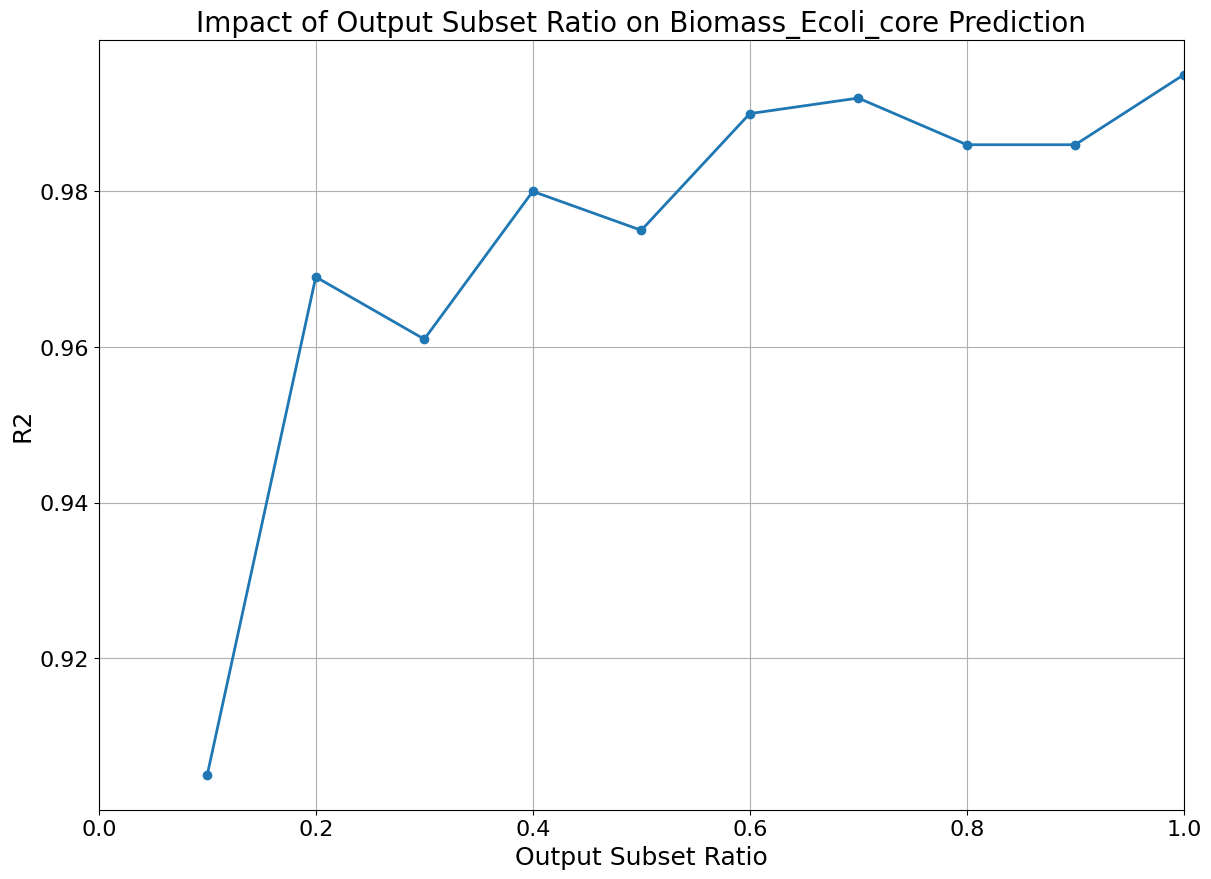

In [ ]:
plot_output_ratio_metric(ratios, biomass_r2, biomass_col, metric_name='r2')

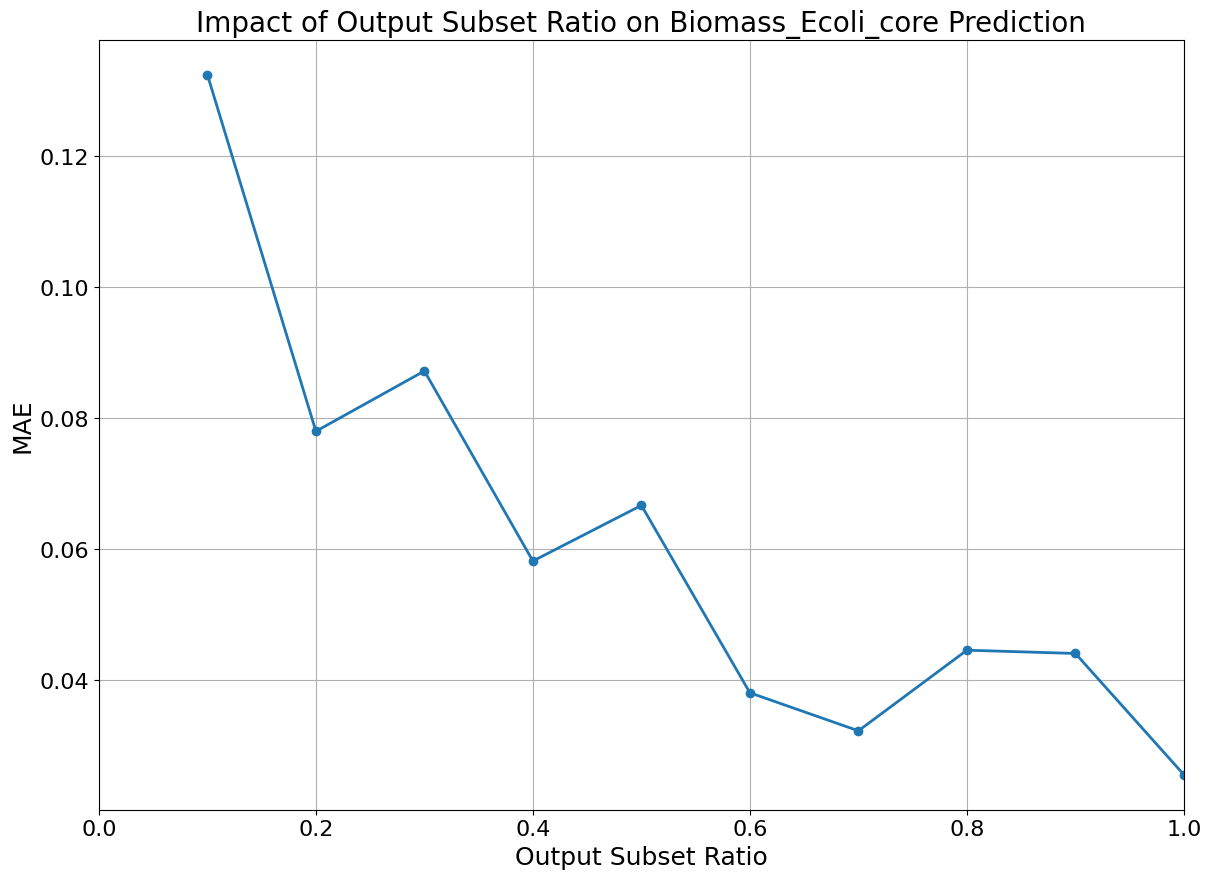

In [ ]:
plot_output_ratio_metric(ratios, biomass_mae, biomass_col, metric_name='mae')

### Exploring Model Variants

The following cells test multiple Transformer configurations with varying model sizes, attention heads, and feedforward dimensions. Each variant is trained, evaluated, and visualized to assess its performance and scalability.

In [53]:
output_sample_ratio = 1

diagnostics_to_plot = ['BIOMASS_Ecoli_core_w_GAM', 'GLUDy_for']

In [54]:
print_gpu_memory()

MPS Allocated memory: 40.45 MB
MPS Driver allocated memory: 1190.66 MB


Epoch 2/200 | Train Loss: 3.277620 | Test Loss: 3.089685
Epoch 4/200 | Train Loss: 2.848301 | Test Loss: 2.540291
Epoch 6/200 | Train Loss: 2.220651 | Test Loss: 2.163279
Epoch 8/200 | Train Loss: 1.941961 | Test Loss: 1.868516
Epoch 10/200 | Train Loss: 1.760661 | Test Loss: 1.803012
Epoch 12/200 | Train Loss: 1.741724 | Test Loss: 1.688691
Epoch 14/200 | Train Loss: 1.668014 | Test Loss: 1.662293
Epoch 16/200 | Train Loss: 1.601081 | Test Loss: 1.669024
Epoch 18/200 | Train Loss: 1.666098 | Test Loss: 1.600785
Epoch 20/200 | Train Loss: 1.623603 | Test Loss: 1.639749
Epoch 22/200 | Train Loss: 1.631290 | Test Loss: 1.664786
Epoch 24/200 | Train Loss: 1.610285 | Test Loss: 1.491038
Epoch 26/200 | Train Loss: 1.521446 | Test Loss: 1.545145
Epoch 28/200 | Train Loss: 1.547524 | Test Loss: 1.603552
Epoch 30/200 | Train Loss: 1.522674 | Test Loss: 1.515304
Epoch 32/200 | Train Loss: 1.508294 | Test Loss: 1.517327
Epoch 34/200 | Train Loss: 1.518147 | Test Loss: 1.463256
Epoch 36/200 | Tra

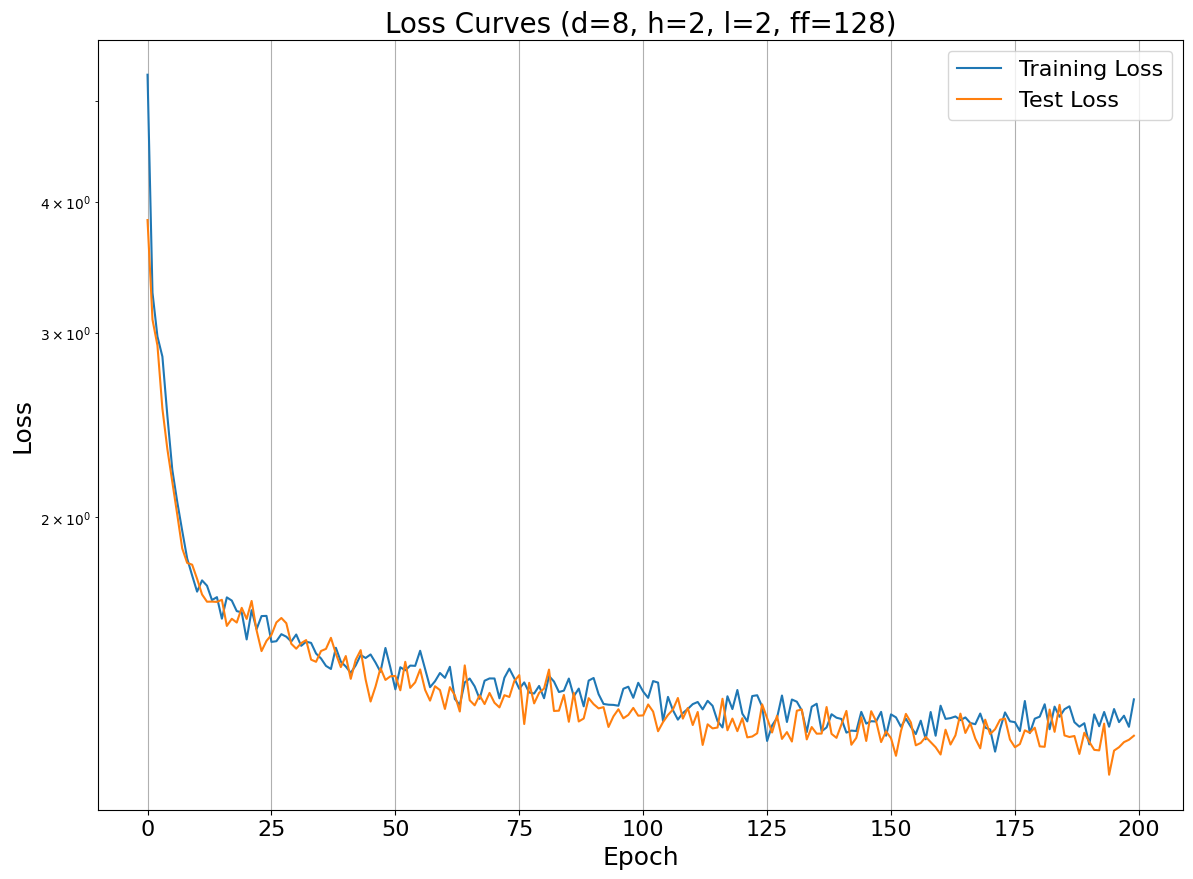

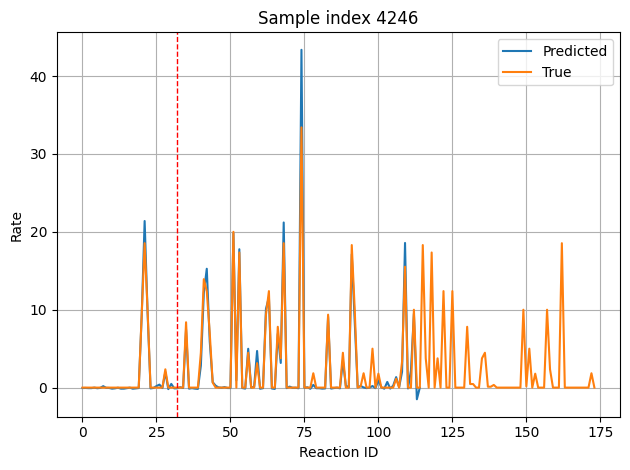

y_pred_outputs.shape: (6160, 95) min/max: -2.4349098 68.24376
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
BIOMASS_Ecoli_core_w_GAM index in outputs: 24
y_true_outputs[:, idx] range: 0.5590506 to 1.2481481
y_pred_outputs[:, _idx] range: 0.430171 to 1.07292


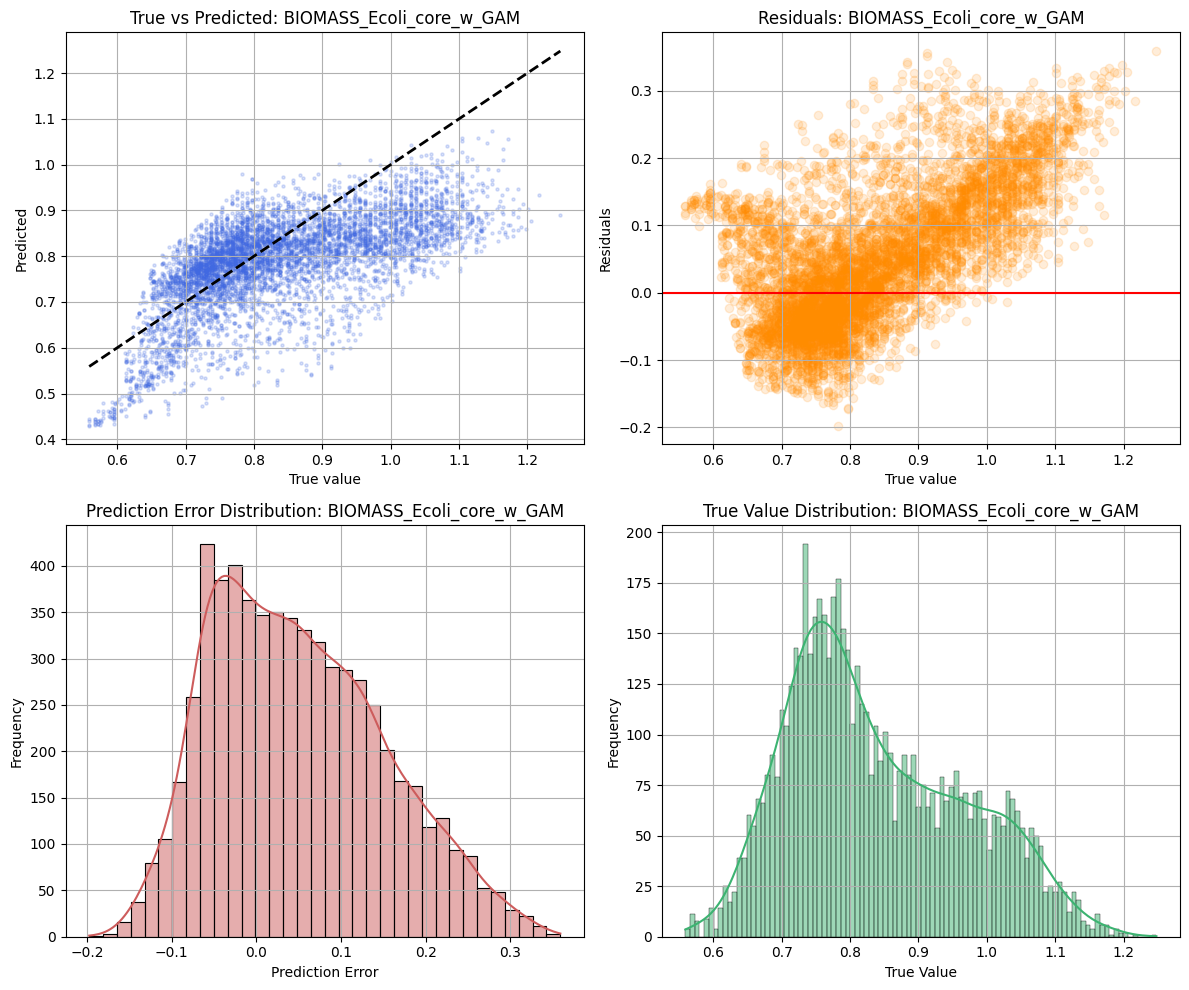

y_pred_outputs.shape: (6160, 95) min/max: -2.4349098 68.24376
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
GLUDy_for index in outputs: 75
y_true_outputs[:, idx] range: 0.0 to 5.187185
y_pred_outputs[:, _idx] range: -0.057952166 to 0.12777114


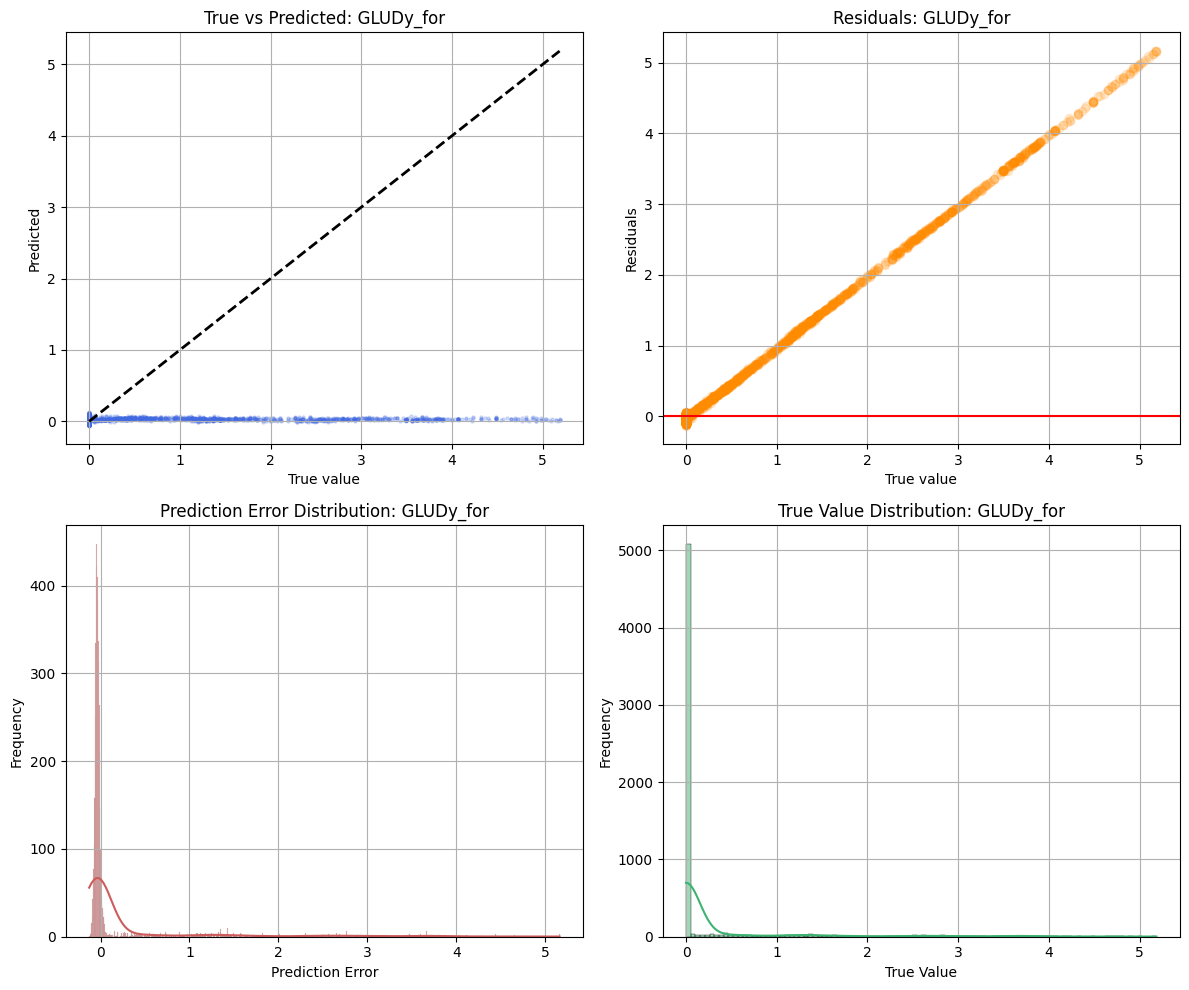

Number of parameters:
6450


In [55]:
train_losses, test_losses, model_822, optimizer = train_model(d_model=8, n_heads=2, n_layers=2, d_ff=128, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses, test_losses, d_model=8, n_heads=2, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_822)

for flux_name in diagnostics_to_plot:
    plot_flux(model_822, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_822.parameters() if p.requires_grad ))

Epoch 2/200 | Train Loss: 3.171381 | Test Loss: 2.981262
Epoch 4/200 | Train Loss: 2.409883 | Test Loss: 2.119144
Epoch 6/200 | Train Loss: 1.785746 | Test Loss: 1.733164
Epoch 8/200 | Train Loss: 1.684931 | Test Loss: 1.653499
Epoch 10/200 | Train Loss: 1.694198 | Test Loss: 1.660918
Epoch 12/200 | Train Loss: 1.678925 | Test Loss: 1.614535
Epoch 14/200 | Train Loss: 1.623307 | Test Loss: 1.531927
Epoch 16/200 | Train Loss: 1.525563 | Test Loss: 1.483186
Epoch 18/200 | Train Loss: 1.510051 | Test Loss: 1.598351
Epoch 20/200 | Train Loss: 1.486840 | Test Loss: 1.496170
Epoch 22/200 | Train Loss: 1.474434 | Test Loss: 1.399532
Epoch 24/200 | Train Loss: 1.468036 | Test Loss: 1.465984
Epoch 26/200 | Train Loss: 1.462812 | Test Loss: 1.440680
Epoch 28/200 | Train Loss: 1.451230 | Test Loss: 1.390656
Epoch 30/200 | Train Loss: 1.470436 | Test Loss: 1.356293
Epoch 32/200 | Train Loss: 1.372076 | Test Loss: 1.321155
Epoch 34/200 | Train Loss: 1.430867 | Test Loss: 1.356314
Epoch 36/200 | Tra

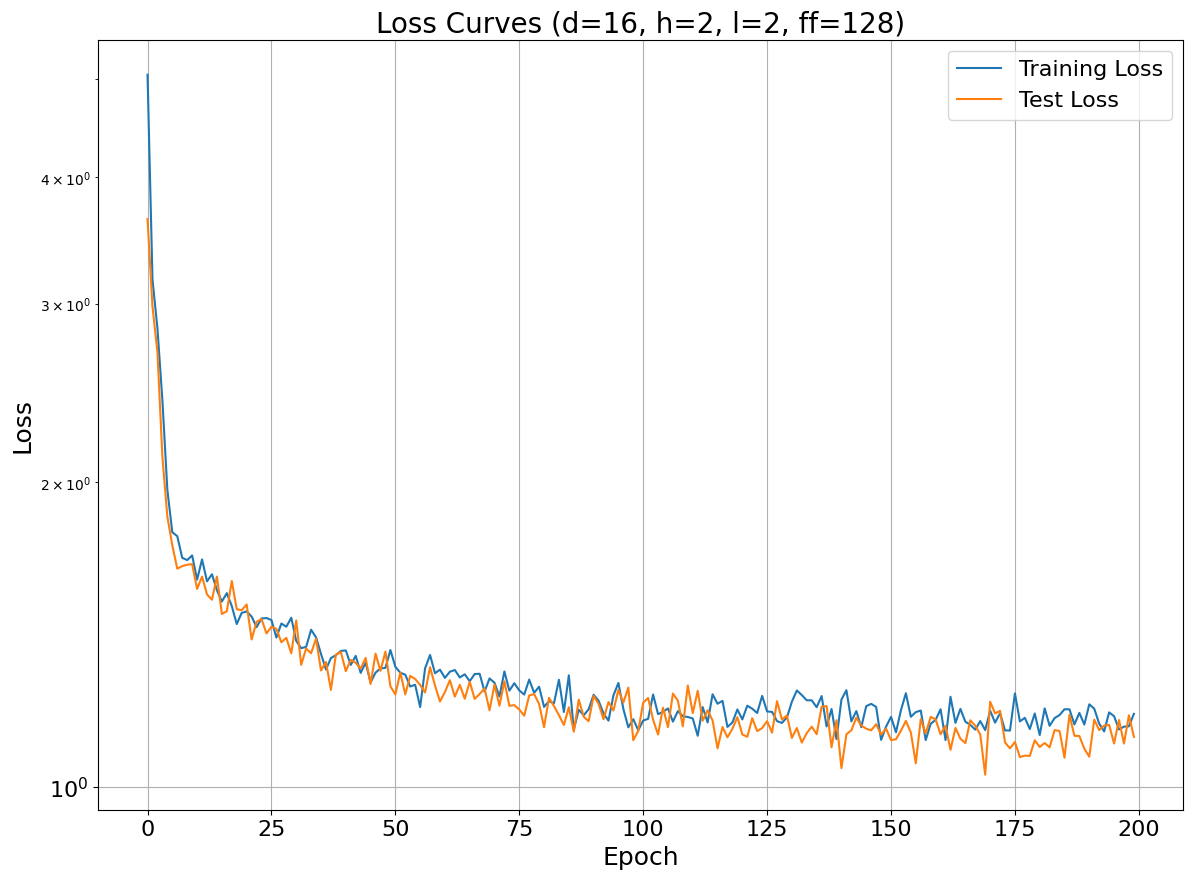

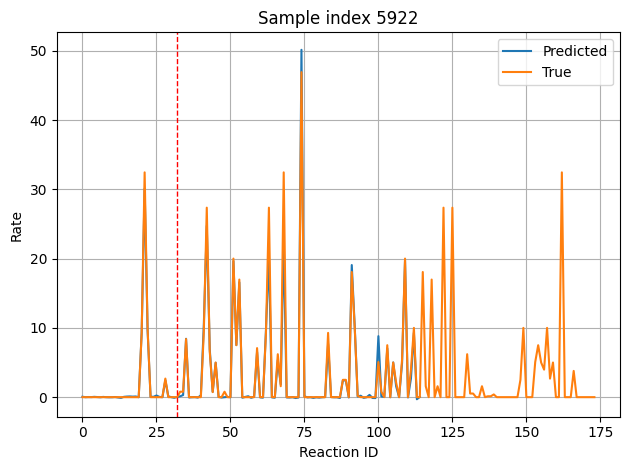

y_pred_outputs.shape: (6160, 95) min/max: -2.4083862 66.629265
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
BIOMASS_Ecoli_core_w_GAM index in outputs: 24
y_true_outputs[:, idx] range: 0.5590506 to 1.2481481
y_pred_outputs[:, _idx] range: 0.55968213 to 1.2221806


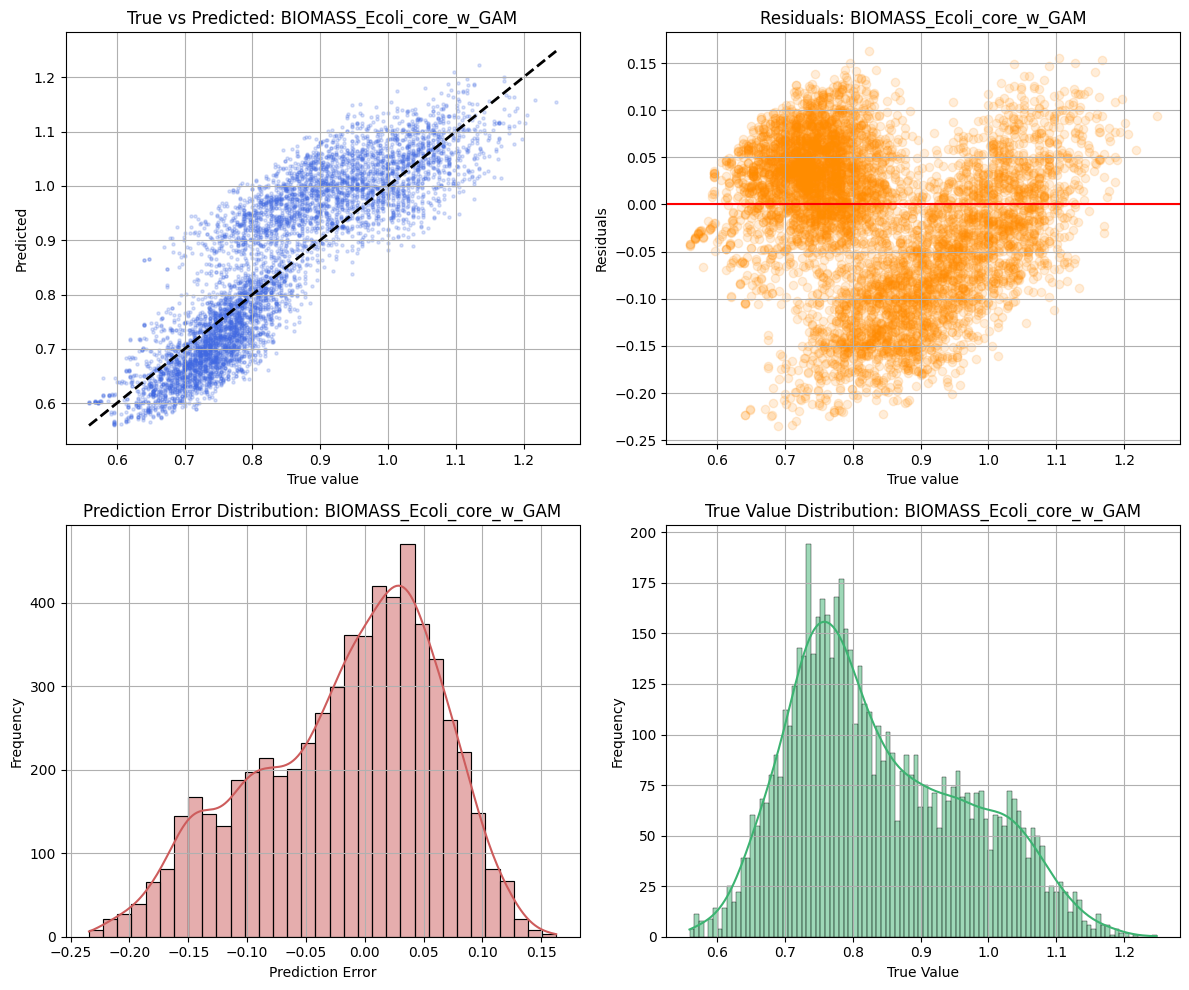

y_pred_outputs.shape: (6160, 95) min/max: -2.4083862 66.629265
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
GLUDy_for index in outputs: 75
y_true_outputs[:, idx] range: 0.0 to 5.187185
y_pred_outputs[:, _idx] range: -0.14734888 to 0.5232965


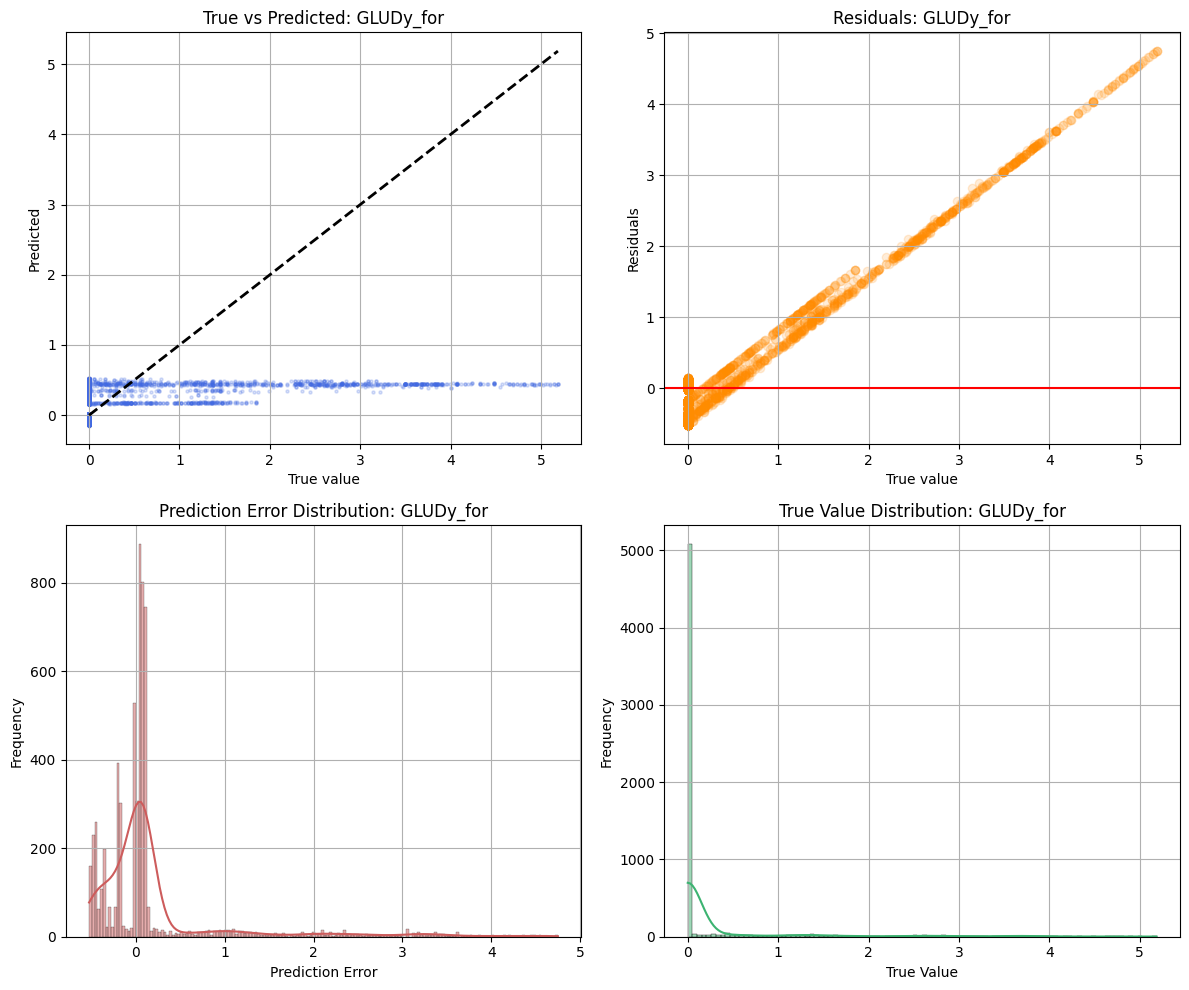

Number of parameters:
13146


In [56]:
train_losses_1622, test_losses_1622, model_1622, optimizer = train_model(d_model=16, n_heads=2, n_layers=2, d_ff=128, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_1622, test_losses_1622, d_model=16, n_heads=2, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_1622)

for flux_name in diagnostics_to_plot:
    plot_flux(model_1622, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_1622.parameters() if p.requires_grad ))

Epoch 2/200 | Train Loss: 1.908289 | Test Loss: 1.644826
Epoch 4/200 | Train Loss: 1.366512 | Test Loss: 1.225828
Epoch 6/200 | Train Loss: 1.071135 | Test Loss: 0.979355
Epoch 8/200 | Train Loss: 0.917187 | Test Loss: 0.806661
Epoch 10/200 | Train Loss: 0.821149 | Test Loss: 0.705798
Epoch 12/200 | Train Loss: 0.730488 | Test Loss: 0.635541
Epoch 14/200 | Train Loss: 0.687022 | Test Loss: 0.596342
Epoch 16/200 | Train Loss: 0.645179 | Test Loss: 0.537761
Epoch 18/200 | Train Loss: 0.600285 | Test Loss: 0.526859
Epoch 20/200 | Train Loss: 0.574821 | Test Loss: 0.491674
Epoch 22/200 | Train Loss: 0.545870 | Test Loss: 0.454780
Epoch 24/200 | Train Loss: 0.529600 | Test Loss: 0.442764
Epoch 26/200 | Train Loss: 0.513795 | Test Loss: 0.430318
Epoch 28/200 | Train Loss: 0.497663 | Test Loss: 0.425804
Epoch 30/200 | Train Loss: 0.488050 | Test Loss: 0.416002
Epoch 32/200 | Train Loss: 0.481060 | Test Loss: 0.411186
Epoch 34/200 | Train Loss: 0.468744 | Test Loss: 0.406986
Epoch 36/200 | Tra

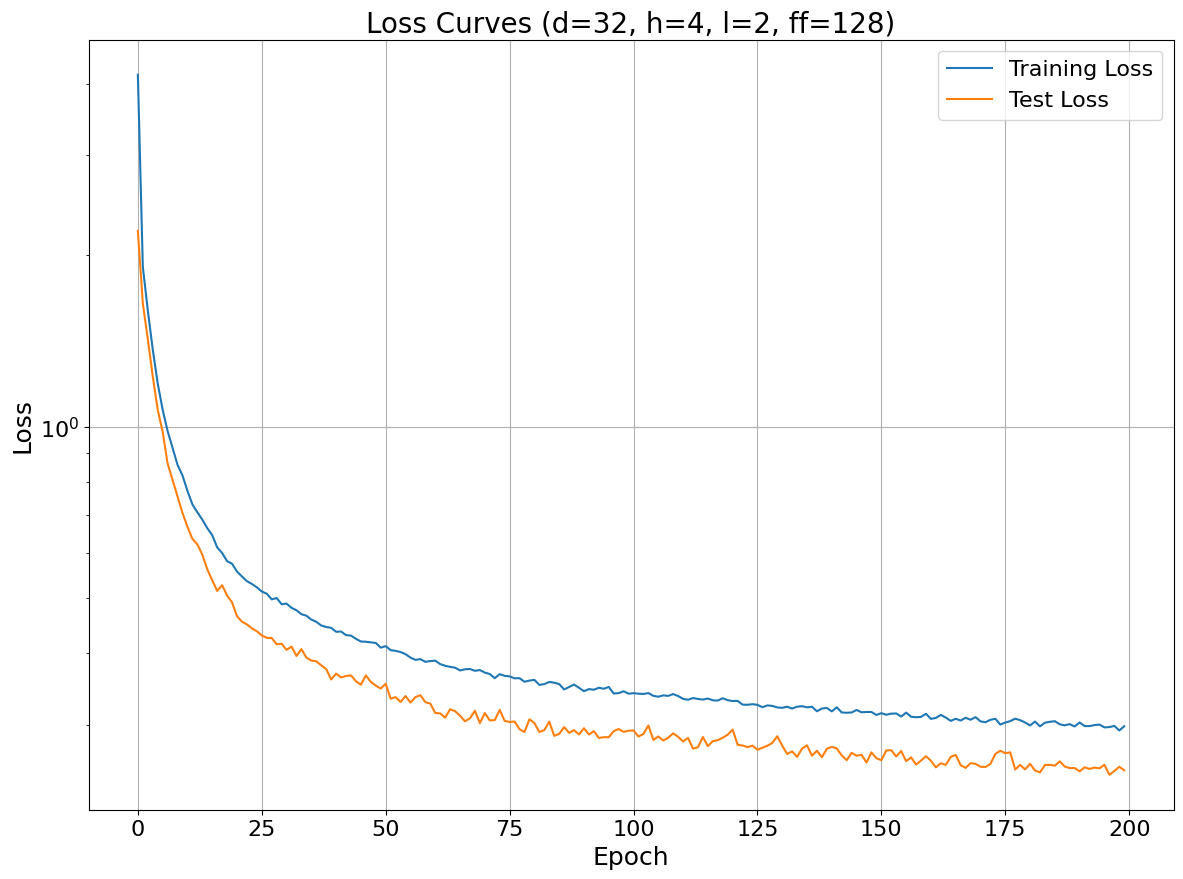

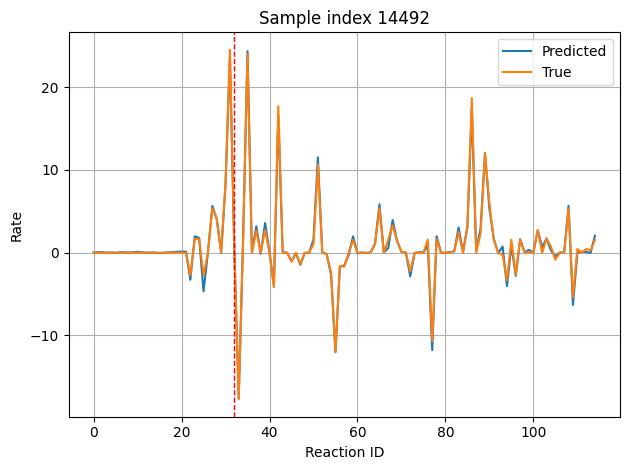

y_pred_outputs.shape: (39227, 95) min/max: -73.75759 107.18997
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.27005243 to 2.1991773


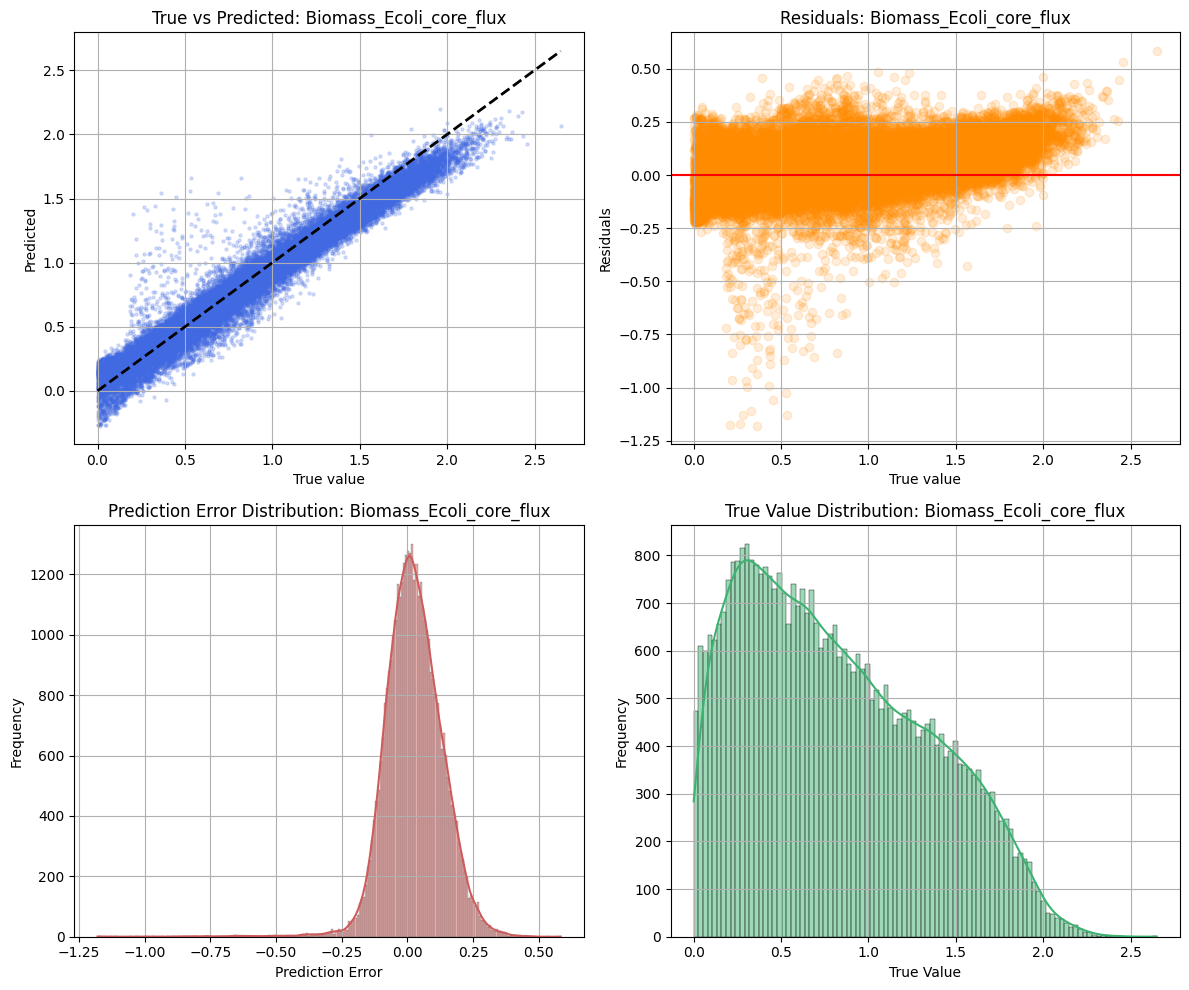

y_pred_outputs.shape: (39227, 95) min/max: -73.75759 107.18997
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -9.631284 to 24.000196


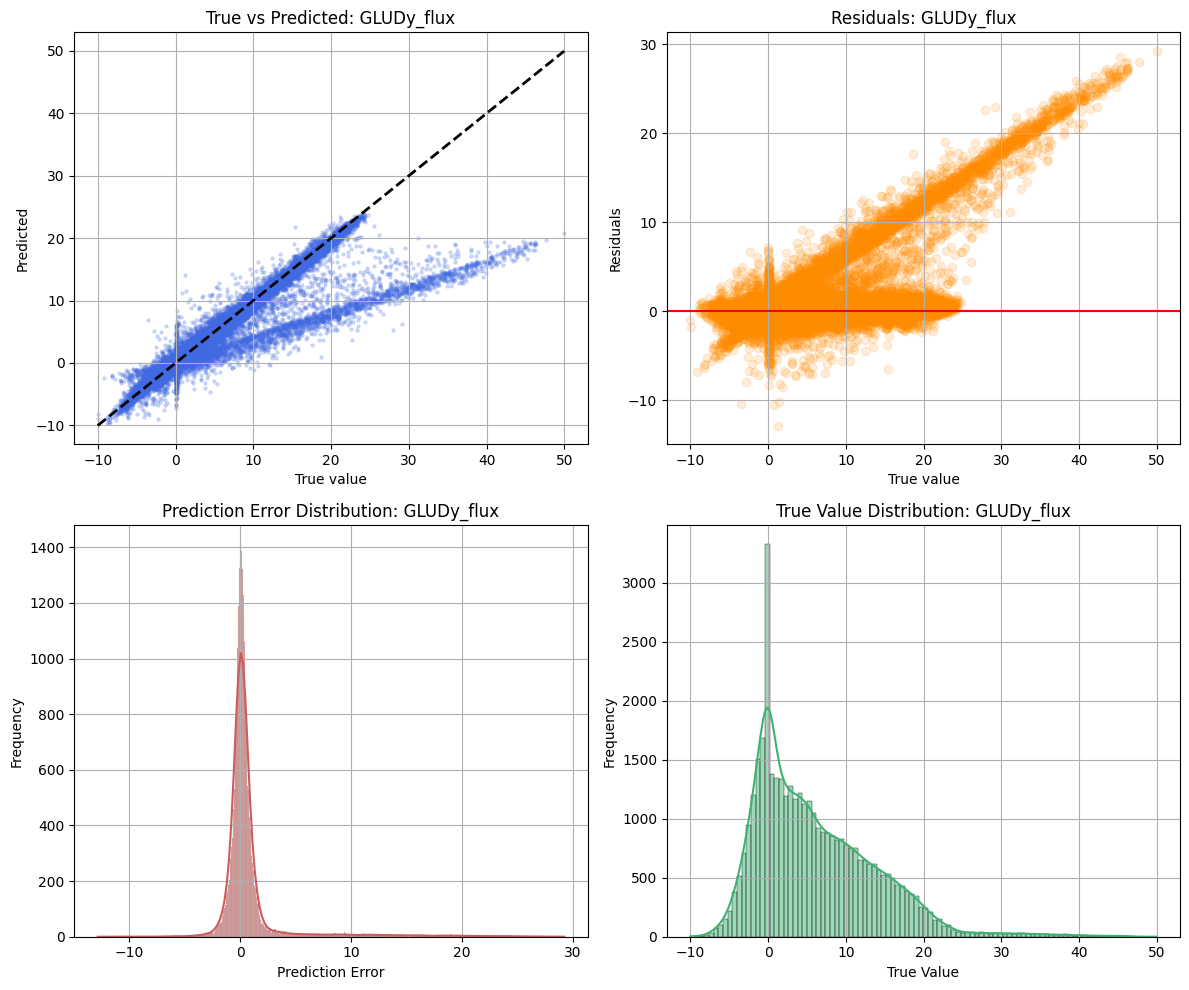

Number of parameters:
29614


In [ ]:
train_losses_3242, test_losses_3242, model_3242, optimizer = train_model(d_model=32, n_heads=4, n_layers=2, d_ff=128, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_3242, test_losses_3242, d_model=32, n_heads=4, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_3242)

for flux_name in diagnostics_to_plot:
    plot_flux(model_3242, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_3242.parameters() if p.requires_grad ))

Epoch 2/200 | Train Loss: 1.893736 | Test Loss: 1.633858
Epoch 4/200 | Train Loss: 1.259913 | Test Loss: 1.178745
Epoch 6/200 | Train Loss: 1.076609 | Test Loss: 0.977560
Epoch 8/200 | Train Loss: 0.944790 | Test Loss: 0.862912
Epoch 10/200 | Train Loss: 0.728956 | Test Loss: 0.651530
Epoch 12/200 | Train Loss: 0.627268 | Test Loss: 0.533827
Epoch 14/200 | Train Loss: 0.567716 | Test Loss: 0.481164
Epoch 16/200 | Train Loss: 0.521864 | Test Loss: 0.456629
Epoch 18/200 | Train Loss: 0.490646 | Test Loss: 0.418910
Epoch 20/200 | Train Loss: 0.450309 | Test Loss: 0.381234
Epoch 22/200 | Train Loss: 0.423060 | Test Loss: 0.359154
Epoch 24/200 | Train Loss: 0.392941 | Test Loss: 0.338503
Epoch 26/200 | Train Loss: 0.382958 | Test Loss: 0.317935
Epoch 28/200 | Train Loss: 0.367856 | Test Loss: 0.300731
Epoch 30/200 | Train Loss: 0.352239 | Test Loss: 0.297240
Epoch 32/200 | Train Loss: 0.342554 | Test Loss: 0.273526
Epoch 34/200 | Train Loss: 0.333909 | Test Loss: 0.290335
Epoch 36/200 | Tra

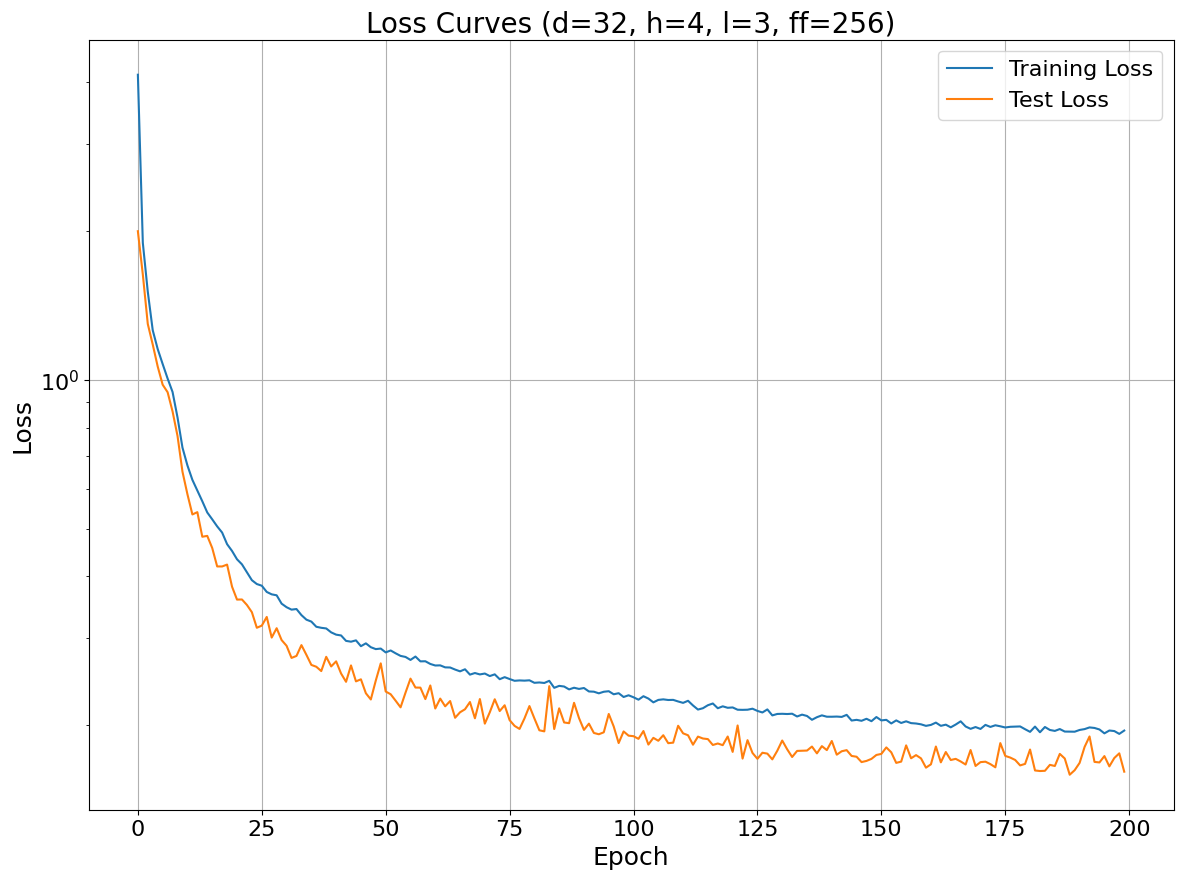

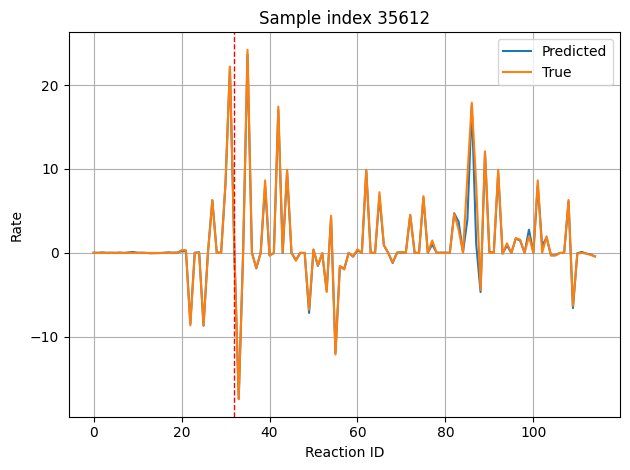

y_pred_outputs.shape: (39227, 95) min/max: -75.484184 108.74066
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.23854256 to 2.3481827


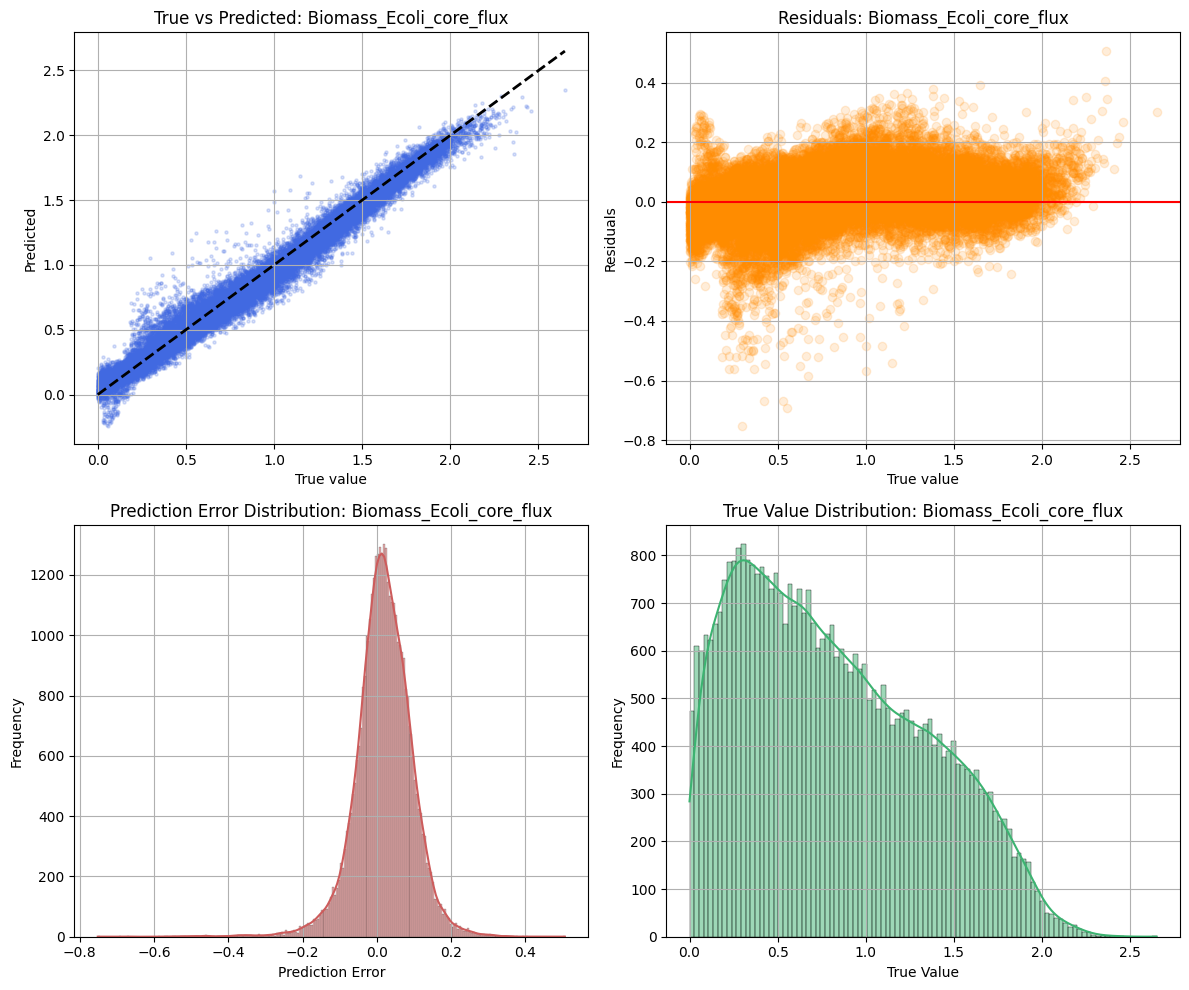

y_pred_outputs.shape: (39227, 95) min/max: -75.484184 108.74066
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -8.703229 to 23.913944


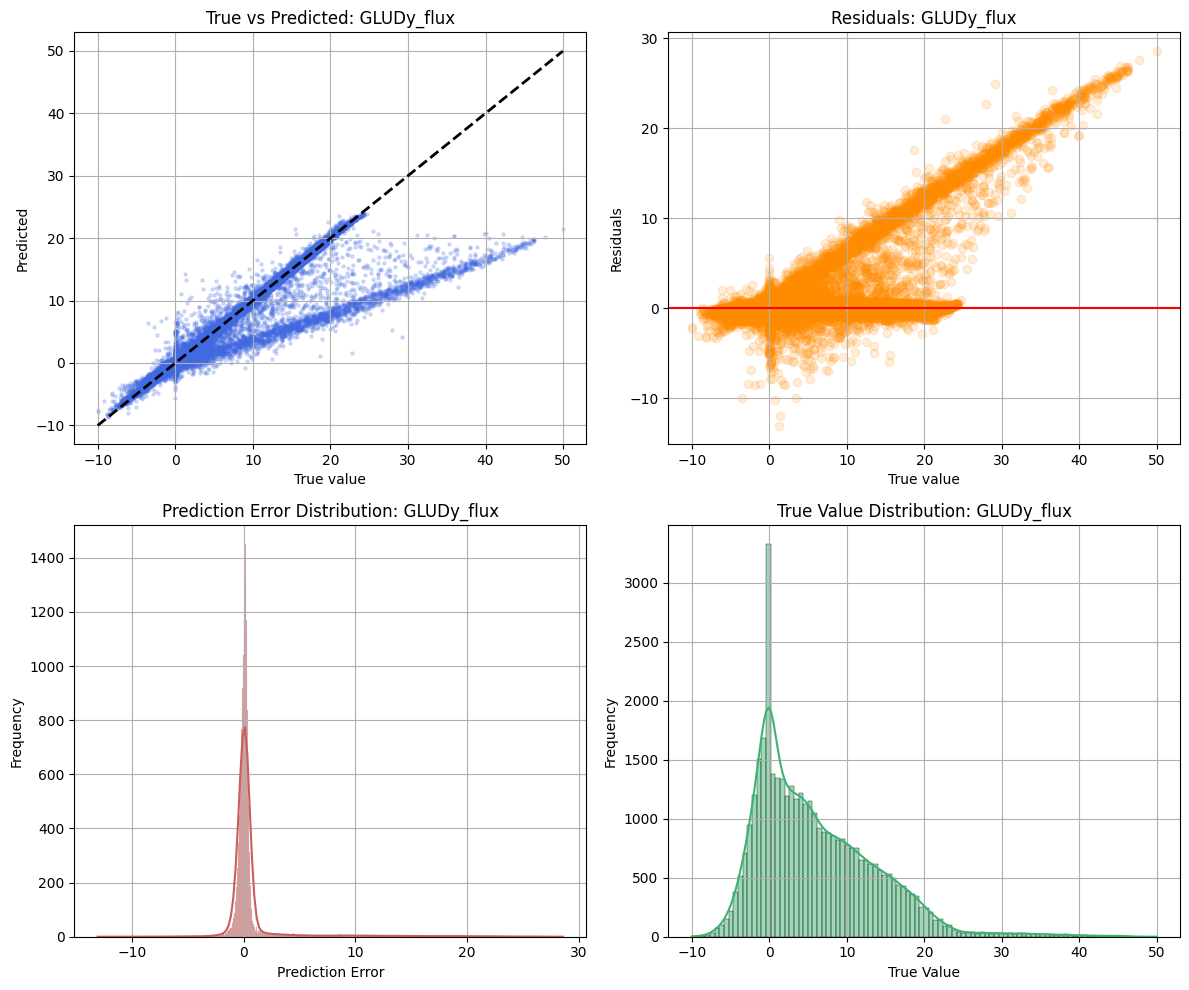

Number of parameters:
68309


In [ ]:
train_losses_3243_256, test_losses_3243_256, model_3243_256, optimizer = train_model(d_model=32, n_heads=4, n_layers=3, d_ff=256, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_3243_256, test_losses_3243_256, d_model=32, n_heads=4, n_layers=3, d_ff=256)

plot_prediction_sample(X_test, y_test, model_3243_256)

for flux_name in diagnostics_to_plot:
    plot_flux(model_3243_256, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_3243_256.parameters() if p.requires_grad ))

Epoch 2/200 | Train Loss: 1.478640 | Test Loss: 1.192719
Epoch 4/200 | Train Loss: 0.895347 | Test Loss: 0.741669
Epoch 6/200 | Train Loss: 0.637512 | Test Loss: 0.572703
Epoch 8/200 | Train Loss: 0.510256 | Test Loss: 0.486411
Epoch 10/200 | Train Loss: 0.441129 | Test Loss: 0.347039
Epoch 12/200 | Train Loss: 0.387136 | Test Loss: 0.339573
Epoch 14/200 | Train Loss: 0.350974 | Test Loss: 0.294631
Epoch 16/200 | Train Loss: 0.323530 | Test Loss: 0.281105
Epoch 18/200 | Train Loss: 0.304284 | Test Loss: 0.314286
Epoch 20/200 | Train Loss: 0.292725 | Test Loss: 0.249412
Epoch 22/200 | Train Loss: 0.283447 | Test Loss: 0.237614
Epoch 24/200 | Train Loss: 0.270377 | Test Loss: 0.216840
Epoch 26/200 | Train Loss: 0.265607 | Test Loss: 0.225192
Epoch 28/200 | Train Loss: 0.257128 | Test Loss: 0.223863
Epoch 30/200 | Train Loss: 0.249680 | Test Loss: 0.208639
Epoch 32/200 | Train Loss: 0.247461 | Test Loss: 0.209326
Epoch 34/200 | Train Loss: 0.242381 | Test Loss: 0.214759
Epoch 36/200 | Tra

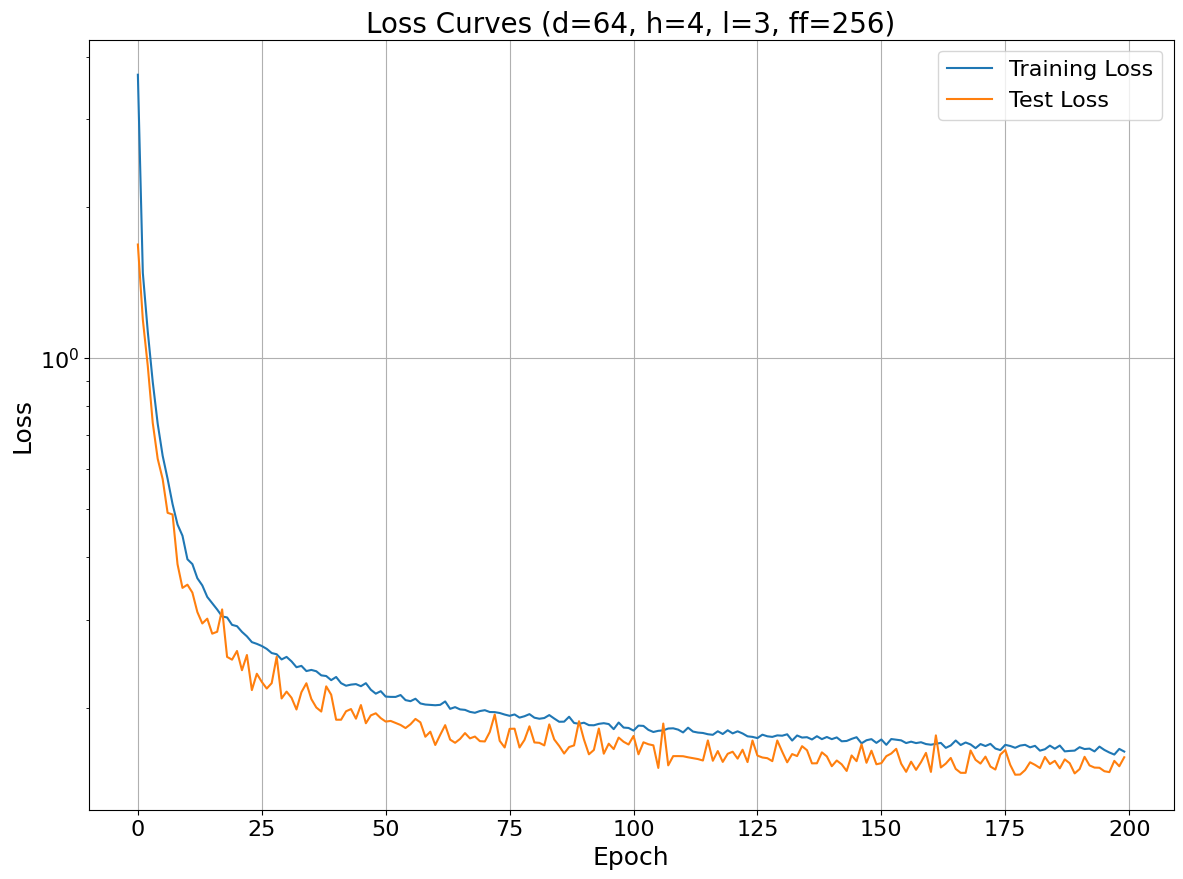

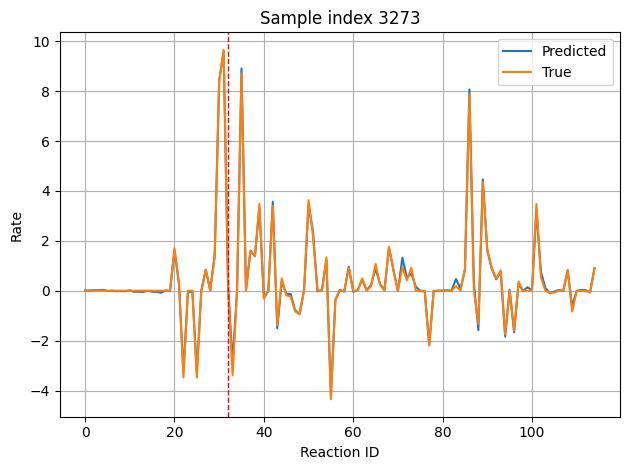

y_pred_outputs.shape: (39227, 95) min/max: -75.81722 105.577194
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.39305592 to 3.0296574


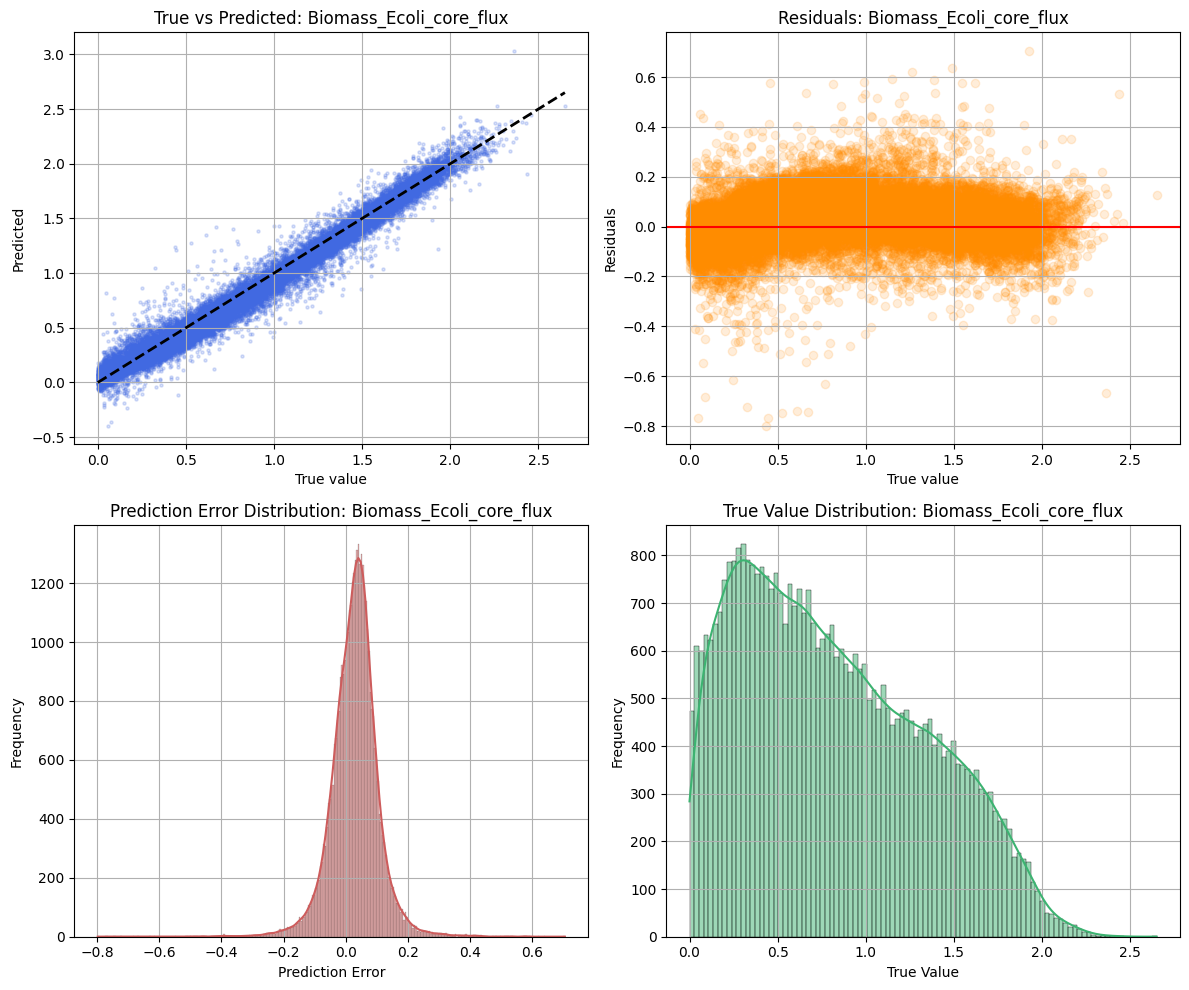

y_pred_outputs.shape: (39227, 95) min/max: -75.81722 105.577194
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -8.712194 to 23.715815


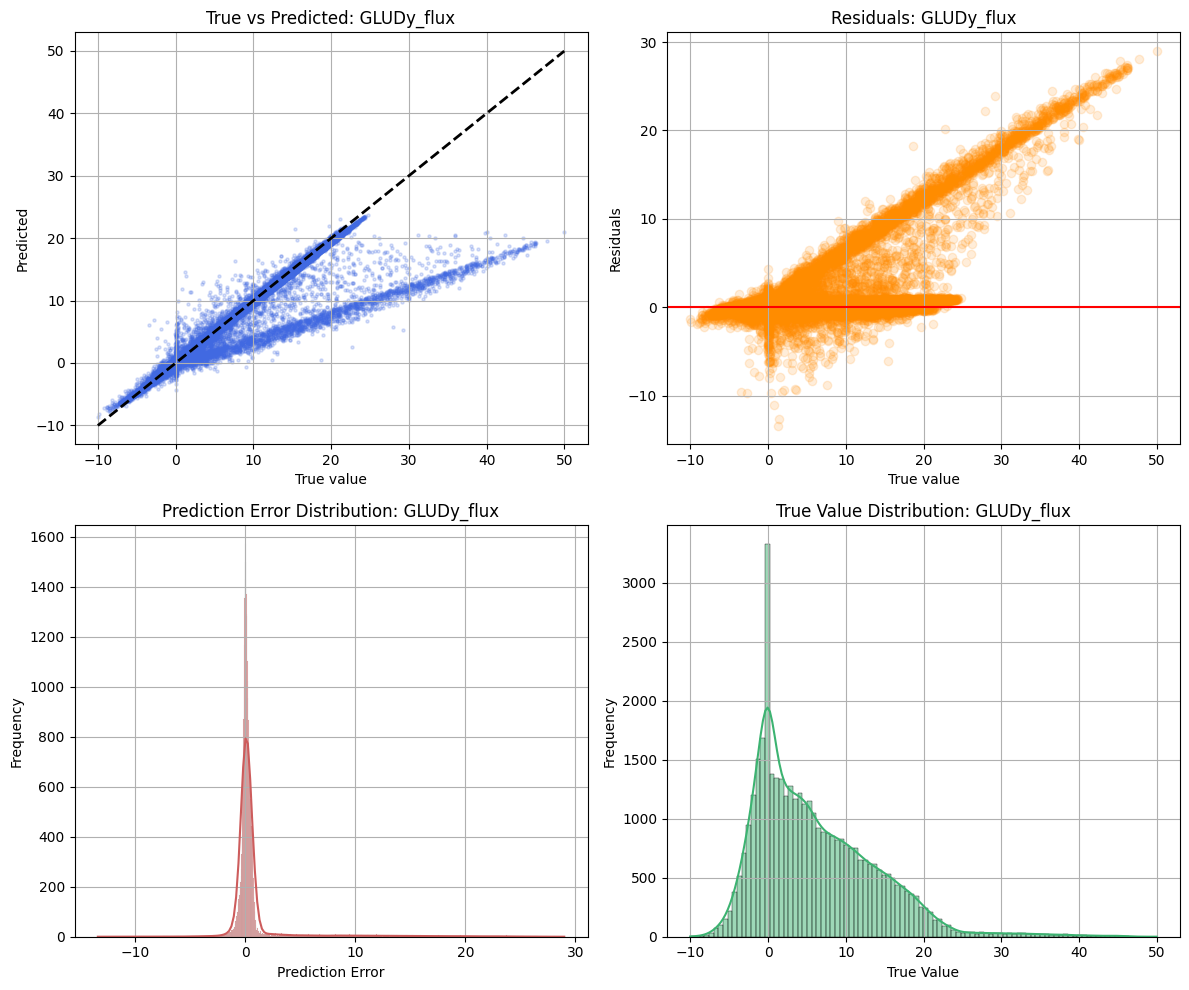

Number of parameters:
158869


In [ ]:
train_losses_6443_256, test_losses_6443_256, model_6443_256, optimizer = train_model(d_model=64, n_heads=4, n_layers=3, d_ff=256, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_6443_256, test_losses_6443_256, d_model=64, n_heads=4, n_layers=3, d_ff=256)

plot_prediction_sample(X_test, y_test, model_6443_256)

for flux_name in diagnostics_to_plot:
    plot_flux(model_6443_256, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_6443_256.parameters() if p.requires_grad ))

Epoch 2/200 | Train Loss: 1.630283 | Test Loss: 1.389902
Epoch 4/200 | Train Loss: 0.932673 | Test Loss: 0.781359
Epoch 6/200 | Train Loss: 0.636665 | Test Loss: 0.539327
Epoch 8/200 | Train Loss: 0.480716 | Test Loss: 0.393169
Epoch 10/200 | Train Loss: 0.408423 | Test Loss: 0.334888
Epoch 12/200 | Train Loss: 0.361826 | Test Loss: 0.327626
Epoch 14/200 | Train Loss: 0.335058 | Test Loss: 0.309032
Epoch 16/200 | Train Loss: 0.315872 | Test Loss: 0.254826
Epoch 18/200 | Train Loss: 0.298706 | Test Loss: 0.254478
Epoch 20/200 | Train Loss: 0.284452 | Test Loss: 0.251145
Epoch 22/200 | Train Loss: 0.274139 | Test Loss: 0.236444
Epoch 24/200 | Train Loss: 0.264536 | Test Loss: 0.233704
Epoch 26/200 | Train Loss: 0.258933 | Test Loss: 0.232190
Epoch 28/200 | Train Loss: 0.251791 | Test Loss: 0.207506
Epoch 30/200 | Train Loss: 0.243353 | Test Loss: 0.219218
Epoch 32/200 | Train Loss: 0.240797 | Test Loss: 0.210635
Epoch 34/200 | Train Loss: 0.234704 | Test Loss: 0.212833
Epoch 36/200 | Tra

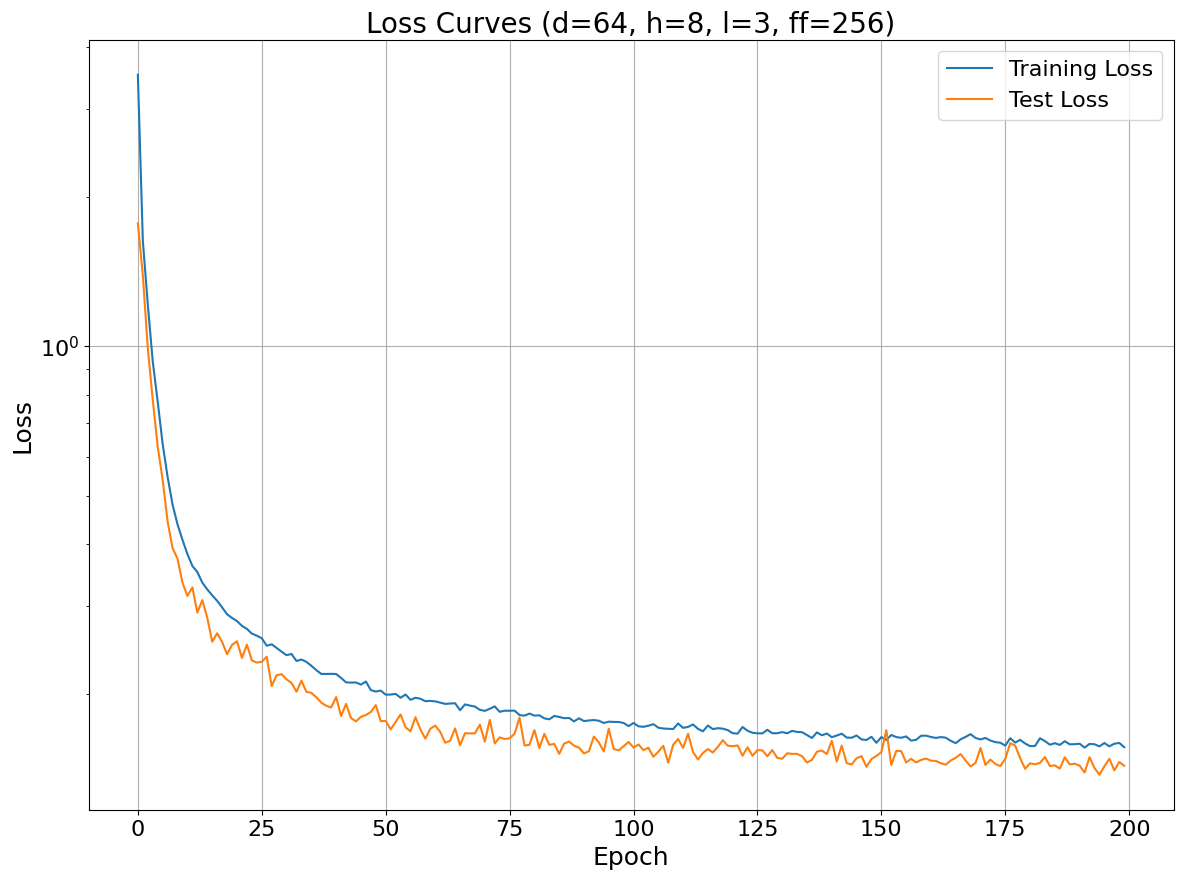

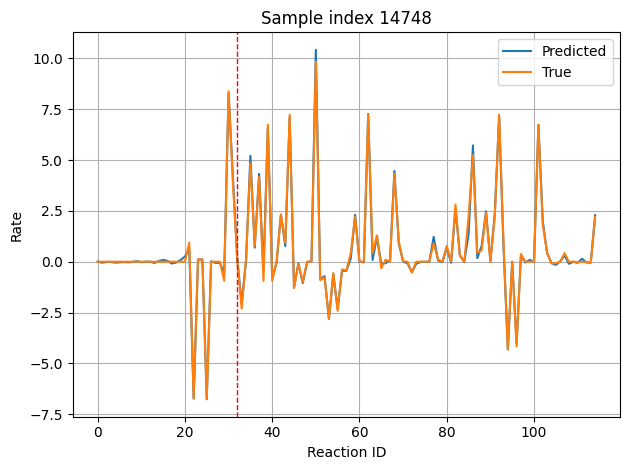

y_pred_outputs.shape: (39227, 95) min/max: -77.897964 107.84478
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.024005577 to 2.3562827


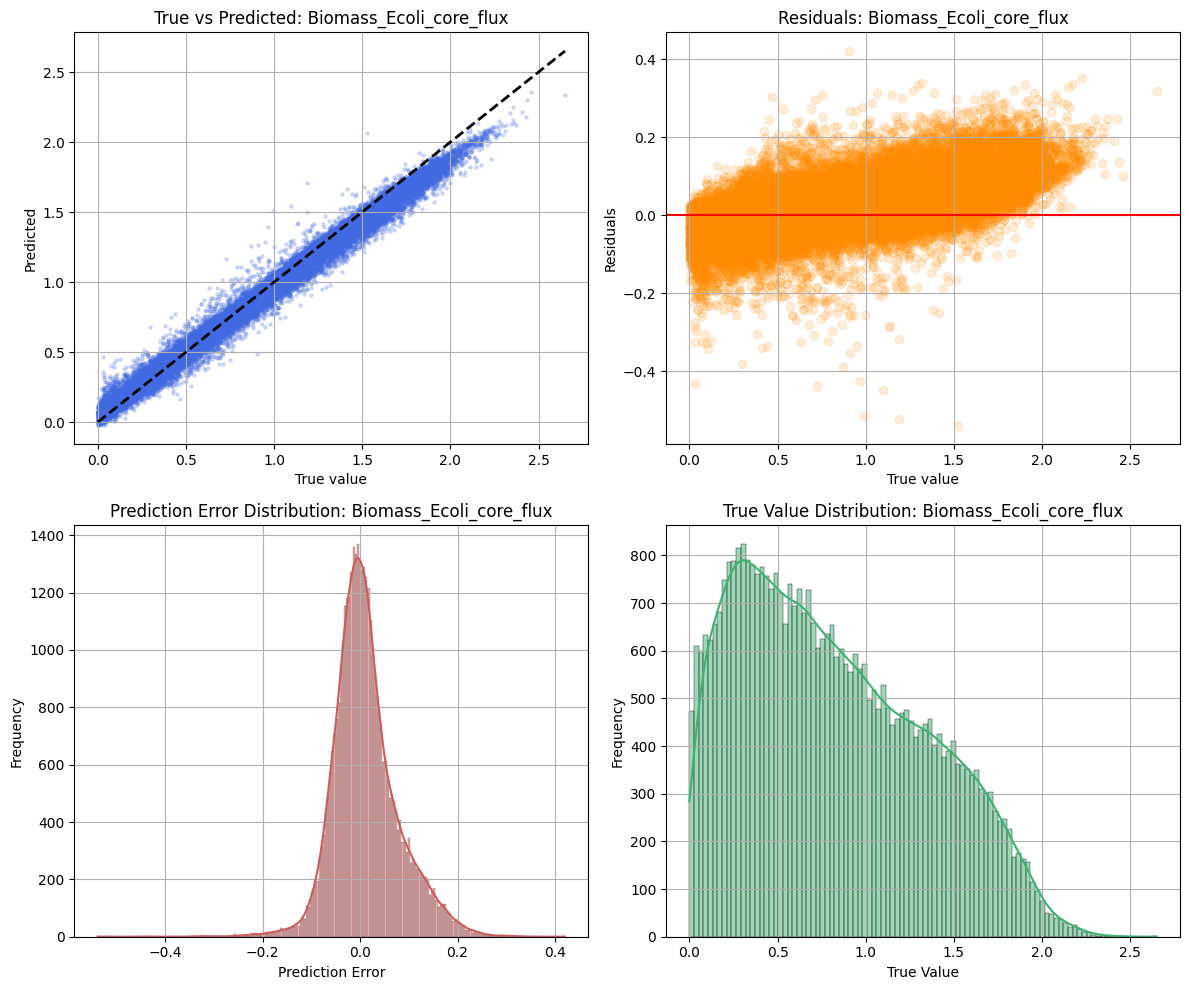

y_pred_outputs.shape: (39227, 95) min/max: -77.897964 107.84478
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -9.568654 to 24.075912


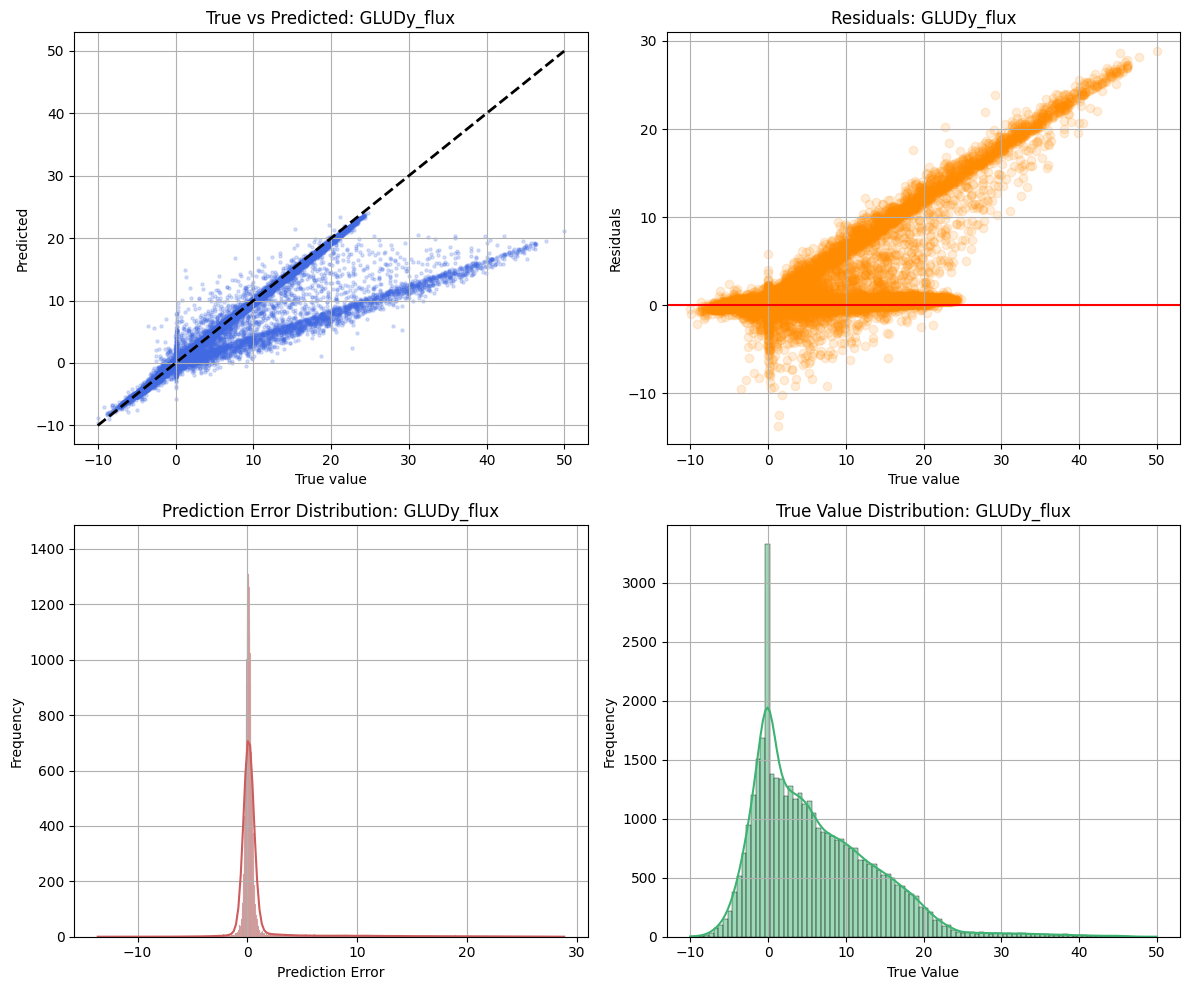

Number of parameters:
158881


In [ ]:
train_losses_6483_256, test_losses_6483_256, model_6483_256, optimizer = train_model(d_model=64, n_heads=8, n_layers=3, d_ff=256, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_6483_256, test_losses_6483_256, d_model=64, n_heads=8, n_layers=3, d_ff=256)

plot_prediction_sample(X_test, y_test, model_6483_256)

for flux_name in diagnostics_to_plot:
    plot_flux(model_6483_256, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_6483_256.parameters() if p.requires_grad ))

Epoch 2/200 | Train Loss: 1.255972 | Test Loss: 1.041370
Epoch 4/200 | Train Loss: 0.734520 | Test Loss: 0.617238
Epoch 6/200 | Train Loss: 0.564100 | Test Loss: 0.467028
Epoch 8/200 | Train Loss: 0.460718 | Test Loss: 0.386354
Epoch 10/200 | Train Loss: 0.394205 | Test Loss: 0.378887
Epoch 12/200 | Train Loss: 0.360638 | Test Loss: 0.321266
Epoch 14/200 | Train Loss: 0.333667 | Test Loss: 0.277896
Epoch 16/200 | Train Loss: 0.307097 | Test Loss: 0.261452
Epoch 18/200 | Train Loss: 0.296294 | Test Loss: 0.245312
Epoch 20/200 | Train Loss: 0.286238 | Test Loss: 0.265062
Epoch 22/200 | Train Loss: 0.271873 | Test Loss: 0.247149
Epoch 24/200 | Train Loss: 0.262219 | Test Loss: 0.218462
Epoch 26/200 | Train Loss: 0.253209 | Test Loss: 0.247727
Epoch 28/200 | Train Loss: 0.243462 | Test Loss: 0.226006
Epoch 30/200 | Train Loss: 0.239478 | Test Loss: 0.222978
Epoch 32/200 | Train Loss: 0.232193 | Test Loss: 0.196601
Epoch 34/200 | Train Loss: 0.227858 | Test Loss: 0.197506
Epoch 36/200 | Tra

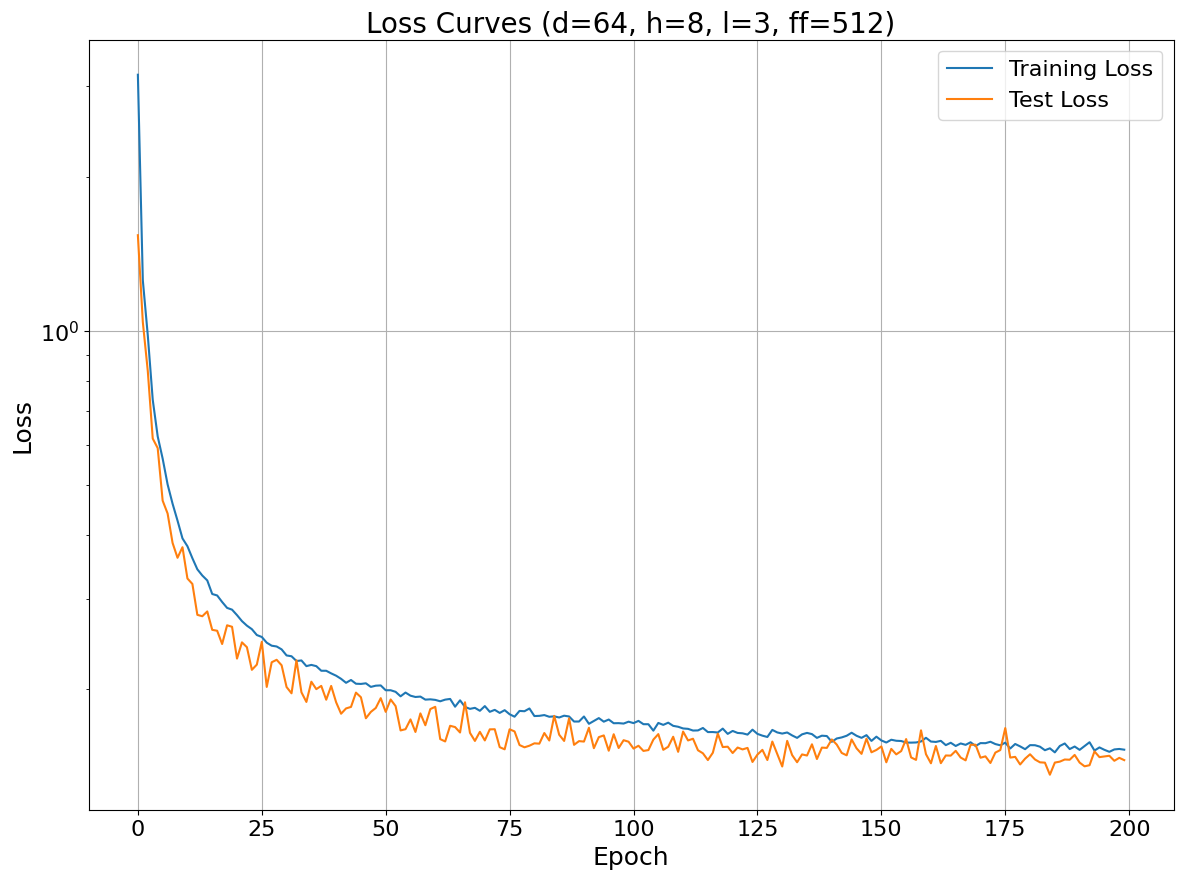

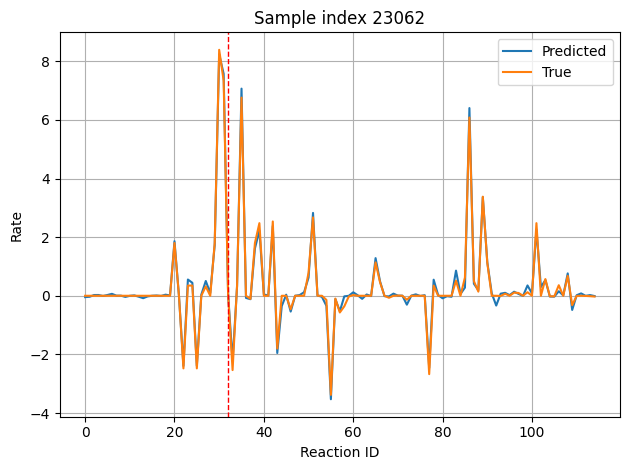

y_pred_outputs.shape: (39227, 95) min/max: -76.20813 107.79582
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.18251562 to 2.4683032


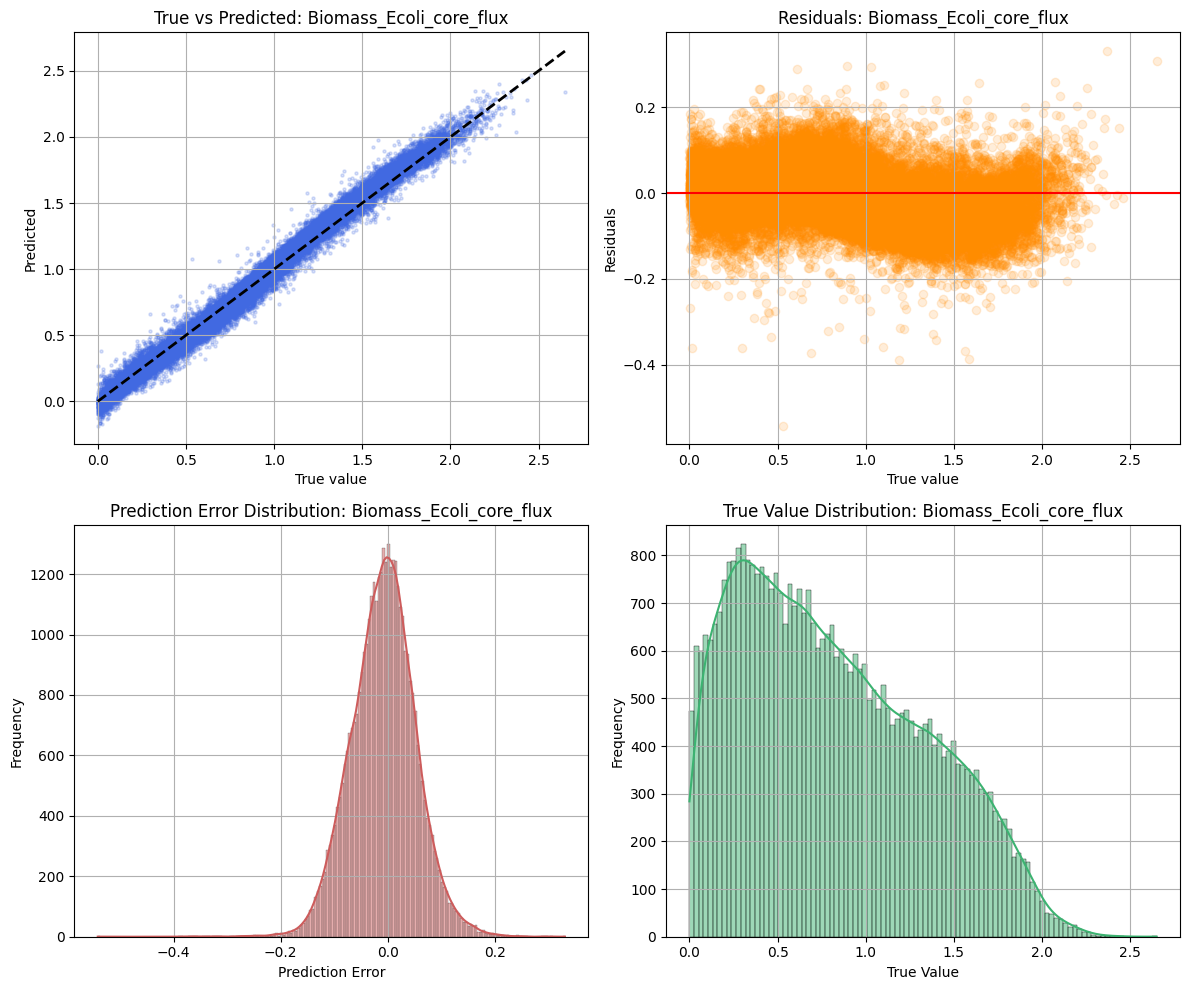

y_pred_outputs.shape: (39227, 95) min/max: -76.20813 107.79582
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -10.289657 to 24.153513


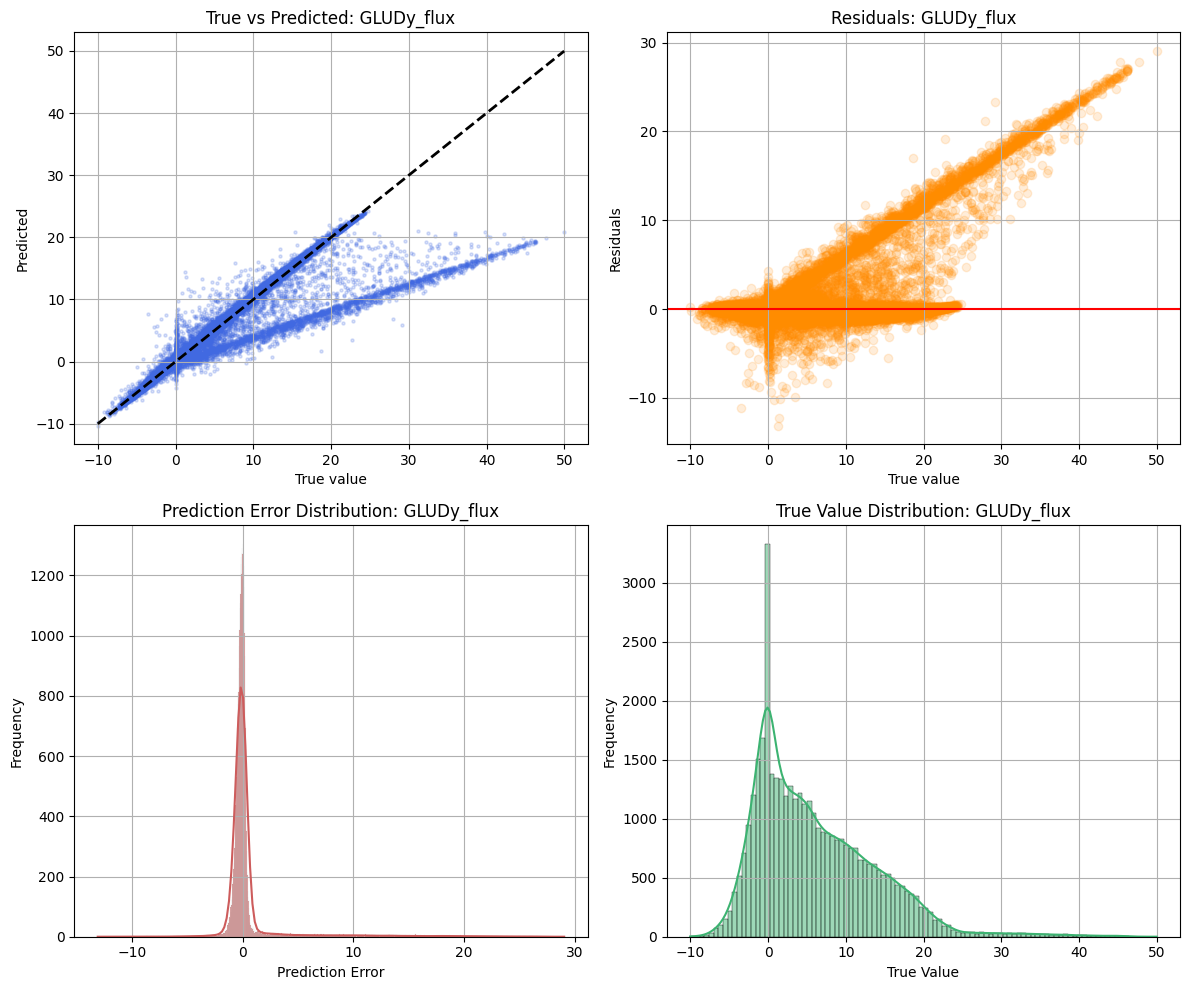

Number of parameters:
259489


In [ ]:

train_losses_6483_512, test_losses_6483_512, model_6483_512, optimizer = train_model(d_model=64, n_heads=8, n_layers=3, d_ff=512, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_6483_512, test_losses_6483_512, d_model=64, n_heads=8, n_layers=3, d_ff=512)

plot_prediction_sample(X_test, y_test, model_6483_512)

for flux_name in diagnostics_to_plot:
    plot_flux(model_6483_512, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_6483_512.parameters() if p.requires_grad ))

Epoch 2/200 | Train Loss: 0.920391 | Test Loss: 0.773724
Epoch 4/200 | Train Loss: 0.594626 | Test Loss: 0.496883
Epoch 6/200 | Train Loss: 0.503182 | Test Loss: 0.441715
Epoch 8/200 | Train Loss: 0.457559 | Test Loss: 0.423089
Epoch 10/200 | Train Loss: 0.409934 | Test Loss: 0.365165
Epoch 12/200 | Train Loss: 0.379381 | Test Loss: 0.338448
Epoch 14/200 | Train Loss: 0.355359 | Test Loss: 0.301311
Epoch 16/200 | Train Loss: 0.340051 | Test Loss: 0.305504
Epoch 18/200 | Train Loss: 0.331992 | Test Loss: 0.322694
Epoch 20/200 | Train Loss: 0.315872 | Test Loss: 0.282506
Epoch 22/200 | Train Loss: 0.313173 | Test Loss: 0.273741
Epoch 24/200 | Train Loss: 0.307353 | Test Loss: 0.264449
Epoch 26/200 | Train Loss: 0.296990 | Test Loss: 0.257174
Epoch 28/200 | Train Loss: 0.290427 | Test Loss: 0.252923
Epoch 30/200 | Train Loss: 0.281494 | Test Loss: 0.249818
Epoch 32/200 | Train Loss: 0.277957 | Test Loss: 0.239518
Epoch 34/200 | Train Loss: 0.272211 | Test Loss: 0.251896
Epoch 36/200 | Tra

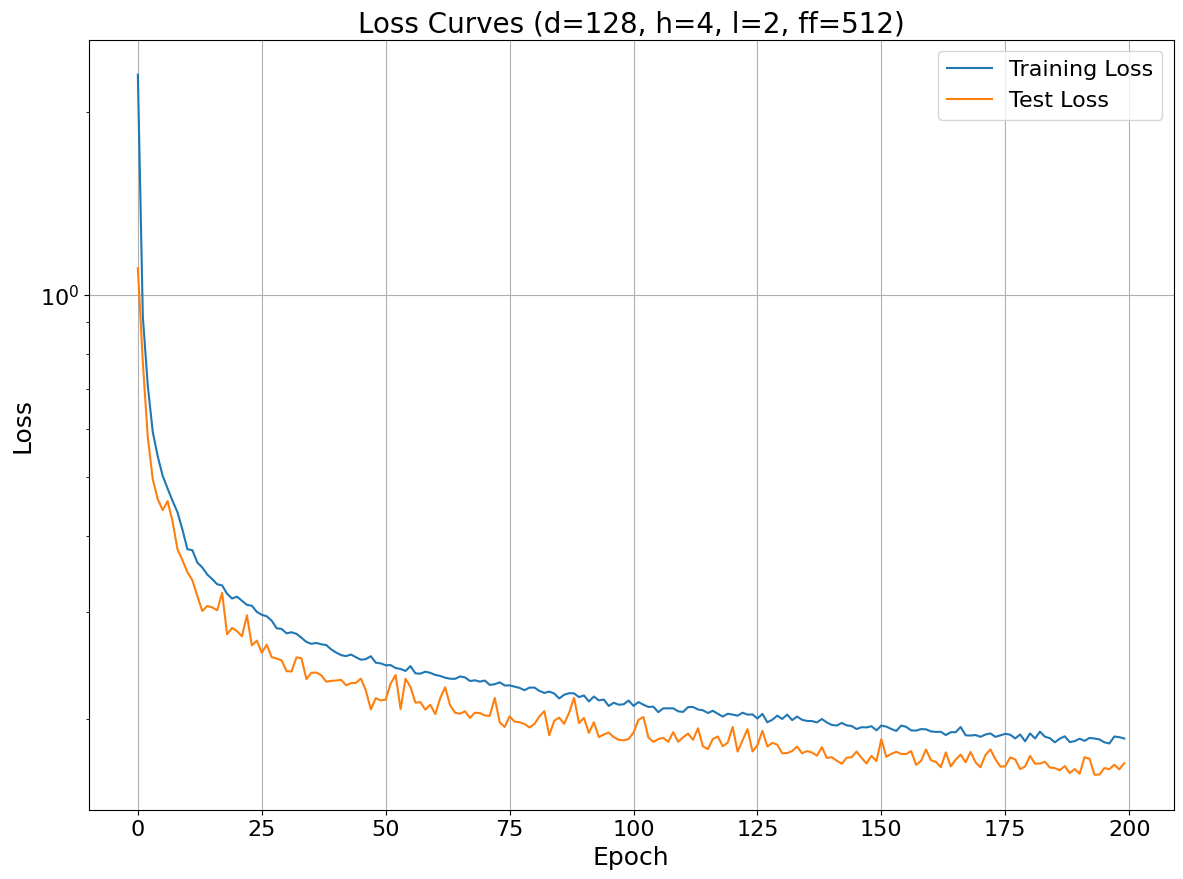

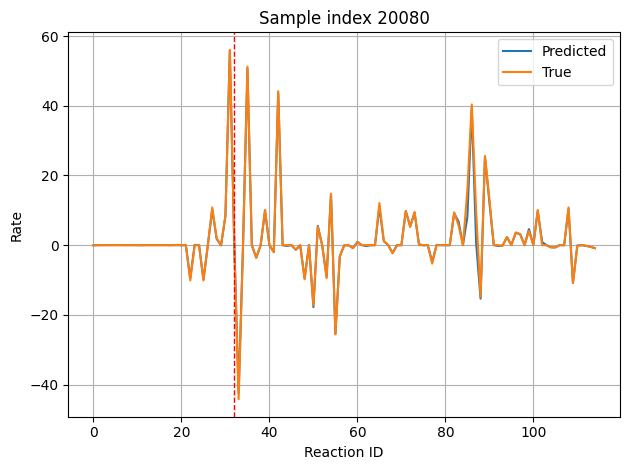

y_pred_outputs.shape: (39227, 95) min/max: -75.780365 109.90796
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.113545835 to 2.4035203


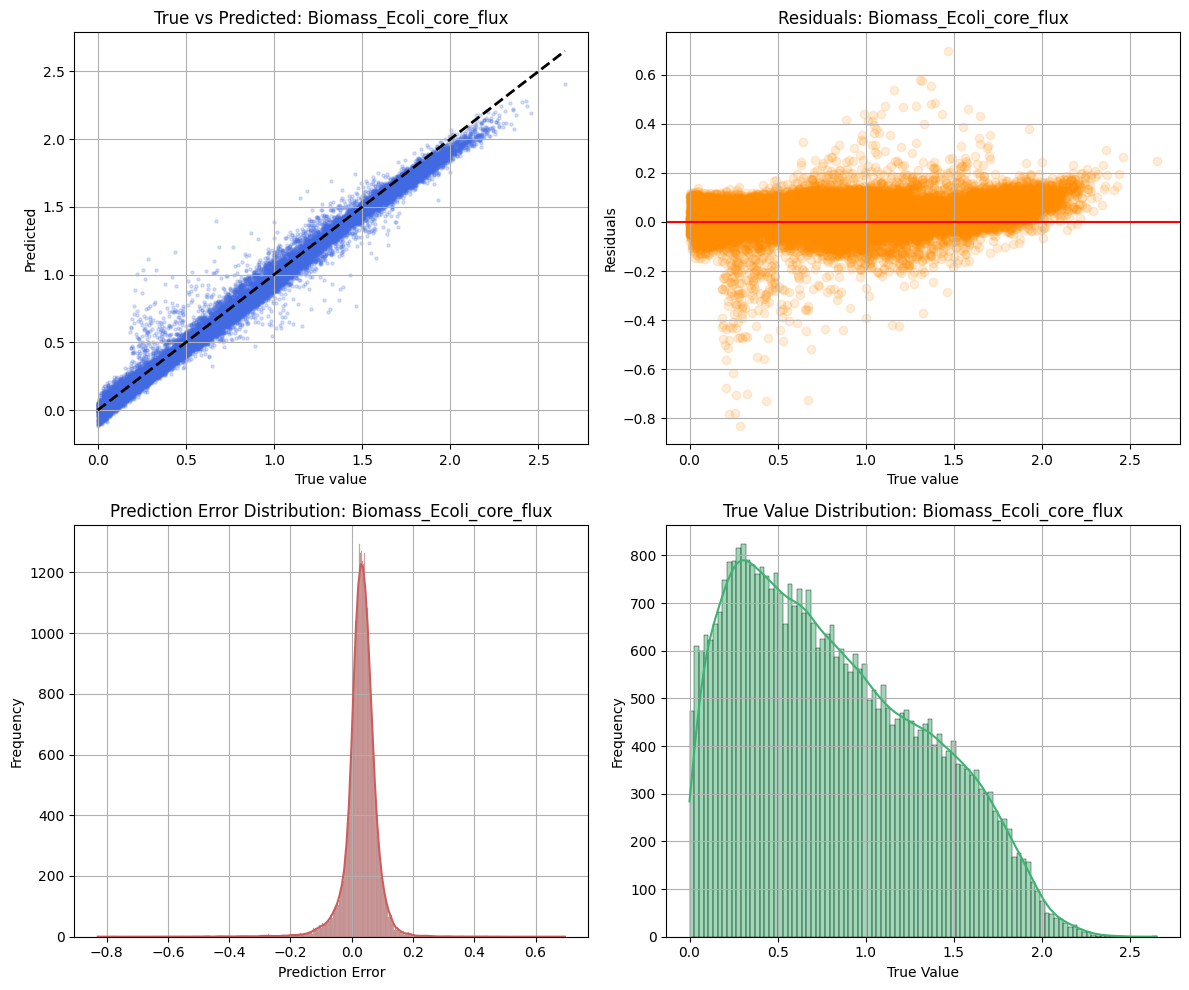

y_pred_outputs.shape: (39227, 95) min/max: -75.780365 109.90796
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -7.7539487 to 24.330032


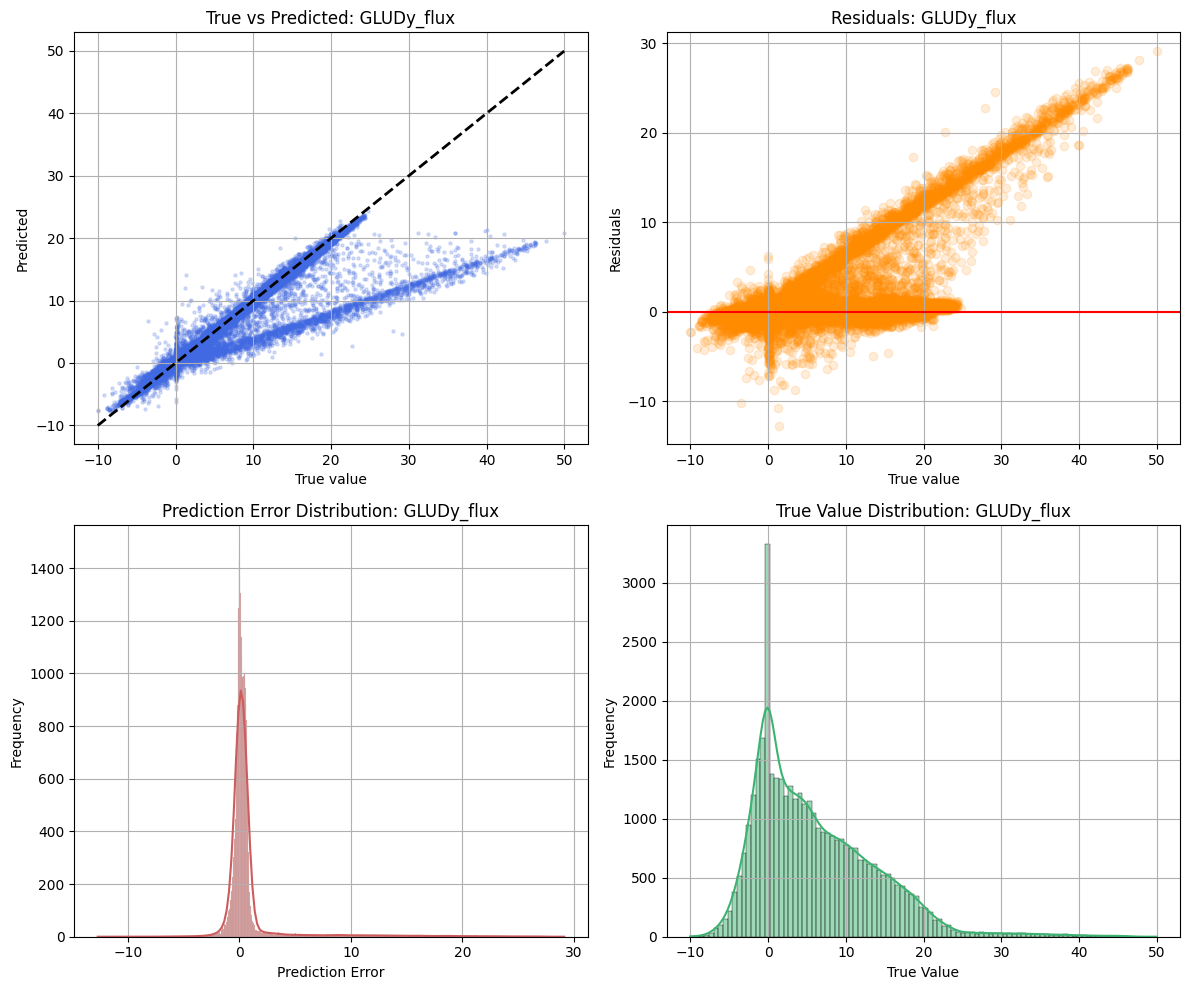

Number of parameters:
413326


In [ ]:

train_losses_12842_512, test_losses_12842_512, model_12842_512, optimizer = train_model(d_model=128, n_heads=4, n_layers=2, d_ff=512, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_12842_512, test_losses_12842_512, d_model=128, n_heads=4, n_layers=2, d_ff=512)

plot_prediction_sample(X_test, y_test, model_12842_512)

for flux_name in diagnostics_to_plot:
    plot_flux(model_12842_512, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_12842_512.parameters() if p.requires_grad ))

Epoch 2/200 | Train Loss: 0.809743 | Test Loss: 0.582395
Epoch 4/200 | Train Loss: 0.435811 | Test Loss: 0.391957
Epoch 6/200 | Train Loss: 0.361699 | Test Loss: 0.298738
Epoch 8/200 | Train Loss: 0.314277 | Test Loss: 0.252358
Epoch 10/200 | Train Loss: 0.289112 | Test Loss: 0.250879
Epoch 12/200 | Train Loss: 0.270998 | Test Loss: 0.241845
Epoch 14/200 | Train Loss: 0.255914 | Test Loss: 0.225796
Epoch 16/200 | Train Loss: 0.246251 | Test Loss: 0.256077
Epoch 18/200 | Train Loss: 0.235720 | Test Loss: 0.202519
Epoch 20/200 | Train Loss: 0.230249 | Test Loss: 0.211433
Epoch 22/200 | Train Loss: 0.224379 | Test Loss: 0.199826
Epoch 24/200 | Train Loss: 0.218254 | Test Loss: 0.196097
Epoch 26/200 | Train Loss: 0.211907 | Test Loss: 0.183709
Epoch 28/200 | Train Loss: 0.208046 | Test Loss: 0.189000
Epoch 30/200 | Train Loss: 0.205963 | Test Loss: 0.193035
Epoch 32/200 | Train Loss: 0.201359 | Test Loss: 0.195794
Epoch 34/200 | Train Loss: 0.195792 | Test Loss: 0.177975
Epoch 36/200 | Tra

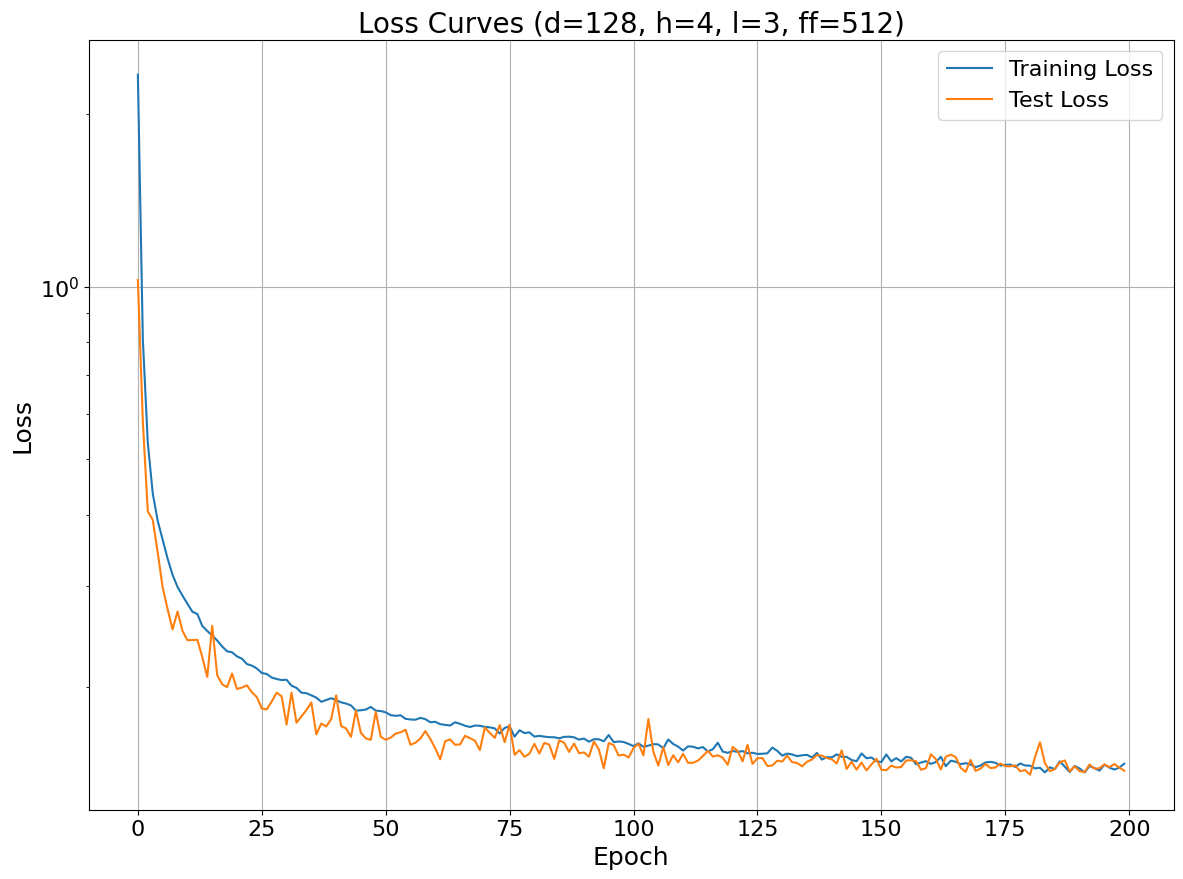

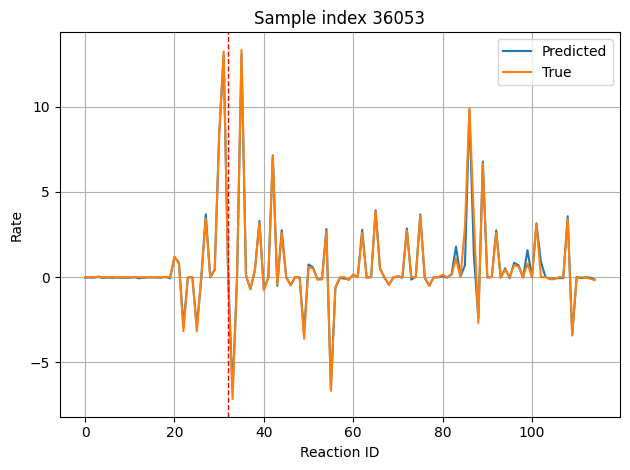

y_pred_outputs.shape: (39227, 95) min/max: -77.58652 108.84718
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Biomass_Ecoli_core_flux index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: -0.110735595 to 2.5151885


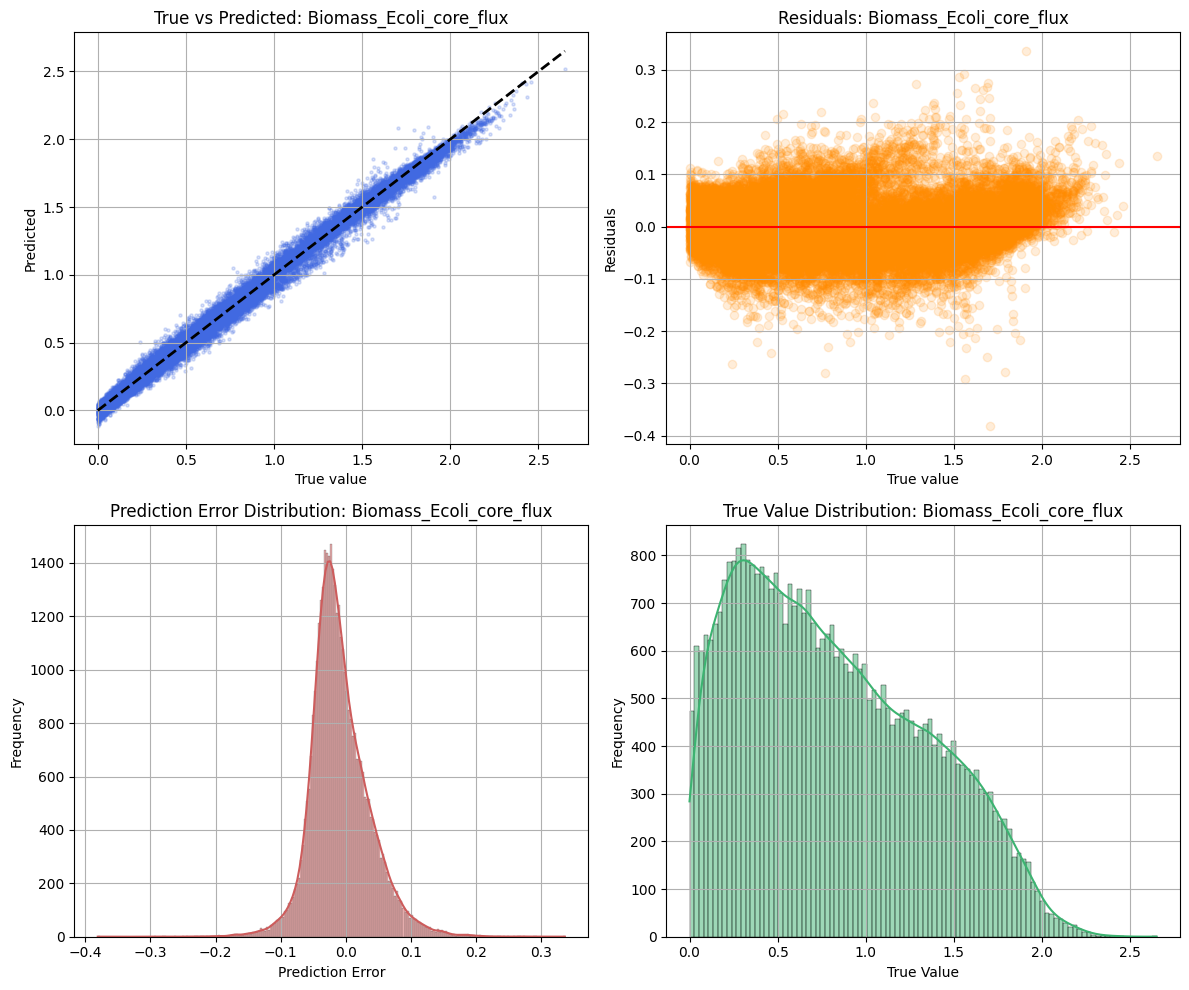

y_pred_outputs.shape: (39227, 95) min/max: -77.58652 108.84718
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
GLUDy_flux index in outputs: 52
y_true_outputs[:, idx] range: -10.018521 to 49.970127
y_pred_outputs[:, _idx] range: -10.18199 to 24.880785


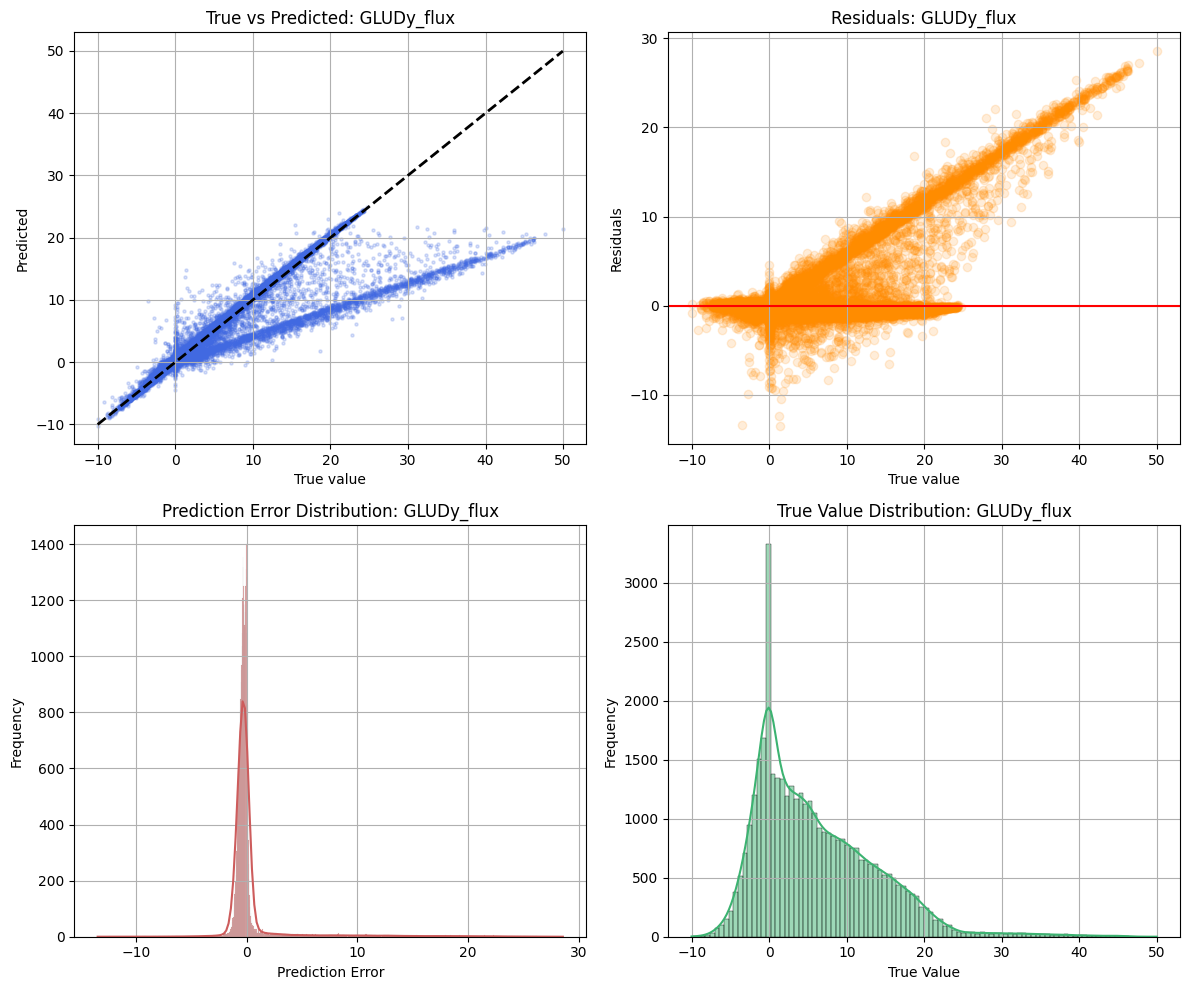

Number of parameters:
612629


In [ ]:

train_losses_12843_512, test_losses_12843_512, model_12843_512, optimizer = train_model(d_model=128, n_heads=4, n_layers=3, d_ff=512, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_12843_512, test_losses_12843_512, d_model=128, n_heads=4, n_layers=3, d_ff=512)

plot_prediction_sample(X_test, y_test, model_12843_512)

for flux_name in diagnostics_to_plot:
    plot_flux(model_12843_512, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_12843_512.parameters() if p.requires_grad ))

Epoch 2/200 | Train Loss: 0.868964 | Test Loss: 0.639275
Epoch 4/200 | Train Loss: 0.413566 | Test Loss: 0.350637
Epoch 6/200 | Train Loss: 0.330754 | Test Loss: 0.267428
Epoch 8/200 | Train Loss: 0.290138 | Test Loss: 0.244037
Epoch 10/200 | Train Loss: 0.259770 | Test Loss: 0.227251
Epoch 12/200 | Train Loss: 0.245131 | Test Loss: 0.226367
Epoch 14/200 | Train Loss: 0.233087 | Test Loss: 0.226378
Epoch 16/200 | Train Loss: 0.221615 | Test Loss: 0.216180
Epoch 18/200 | Train Loss: 0.214612 | Test Loss: 0.200180
Epoch 20/200 | Train Loss: 0.212365 | Test Loss: 0.190732
Epoch 22/200 | Train Loss: 0.204763 | Test Loss: 0.180165
Epoch 24/200 | Train Loss: 0.199359 | Test Loss: 0.173949
Epoch 26/200 | Train Loss: 0.193062 | Test Loss: 0.169869
Epoch 28/200 | Train Loss: 0.194628 | Test Loss: 0.187904
Epoch 30/200 | Train Loss: 0.189256 | Test Loss: 0.179377
Epoch 32/200 | Train Loss: 0.188947 | Test Loss: 0.171027
Epoch 34/200 | Train Loss: 0.183309 | Test Loss: 0.169889
Epoch 36/200 | Tra

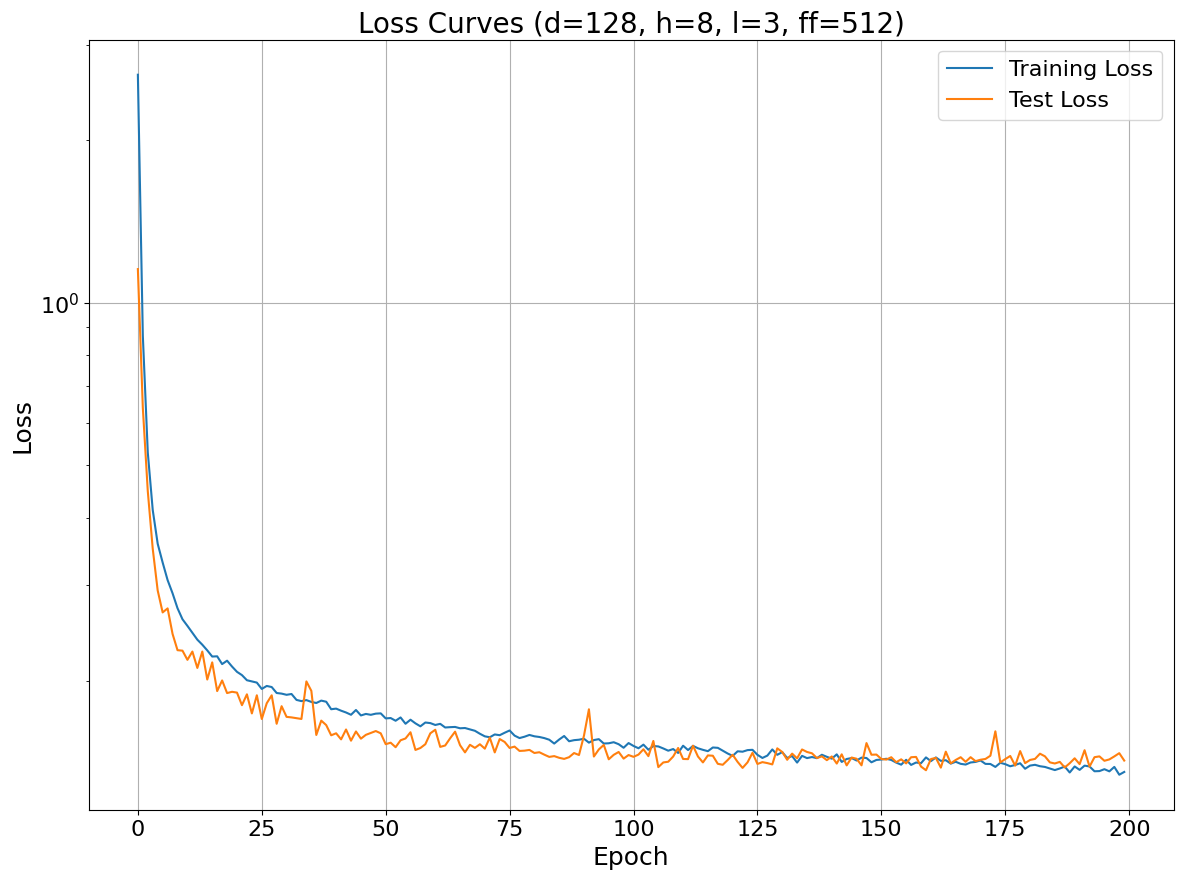

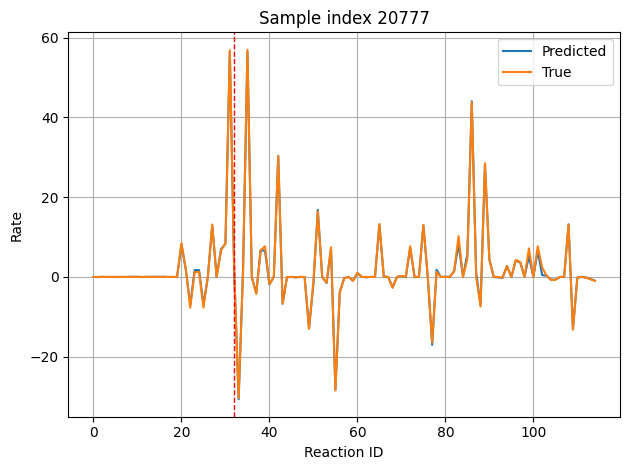

RuntimeError: [enforce fail at alloc_cpu.cpp:114] data. DefaultCPUAllocator: not enough memory: you tried to allocate 16600866400 bytes.

: 

In [ ]:

train_losses_12883_512, test_losses_12883_512, model_12883_512, optimizer = train_model(d_model=128, n_heads=8, n_layers=3, d_ff=512, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_12883_512, test_losses_12883_512, d_model=128, n_heads=8, n_layers=3, d_ff=512)

plot_prediction_sample(X_test, y_test, model_12883_512)

for flux_name in diagnostics_to_plot:
    plot_flux(model_12883_512, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_12883_512.parameters() if p.requires_grad ))